# Worm species classification sweep analysis

This notebook summarises a SLURM/node-local sweep for the worm species classification project.

It is designed for the directory structure shown below:

```text
~/worm-species/
└── outputs_slurm/
    └── node_local_sweep_20260703_164317/
        ├── run_000/
        │   ├── multi_run_results.csv
        │   └── <model_run_name>/
        │       ├── test_metrics.json
        │       ├── classification_report_genus.csv
        │       ├── classification_report_species.csv
        │       ├── classification_report_age.csv
        │       ├── confusion_matrix_genus.csv
        │       ├── confusion_matrix_species.csv
        │       └── confusion_matrix_age.csv
        ├── run_001/
        └── ...
```

The main aim is to:

1. aggregate all `multi_run_results.csv` files;
2. rank runs using a validation metric by default;
3. report species, genus, and age performance;
4. identify the best model folder;
5. plot the classification reports and confusion matrices for the selected best run.

For model selection, the default is `best_val_score`, because choosing the final model by a test-set metric can bias the reported test performance. For diagnosis, the notebook also shows the best runs by species macro-F1.


In [4]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

TASKS = ["species", "genus", "age"]  # species first because this is the main biological target


## 1. Locate the sweep directory

Run this notebook from `~/worm-species` if possible. If you run it from inside the sweep directory, it should also work.


In [5]:
from pathlib import Path

def find_sweep_dirs() -> list[Path]:
    """
    Find one or more sweep directories containing run_*/multi_run_results.csv.

    Works from:
    - ~/worm-species
    - ~/worm-species/outputs_slurm
    - inside a specific sweep directory
    """
    cwd = Path.cwd().expanduser().resolve()

    candidates = []

    # Case 1: running from project root
    candidates.extend(sorted((cwd / "outputs_slurm").glob("node_local_sweep_*")))

    # Case 2: running from outputs_slurm
    candidates.extend(sorted(cwd.glob("node_local_sweep_*")))

    # Case 3: running inside one sweep
    candidates.append(cwd)

    # Case 4: default project path
    candidates.extend(
        sorted(
            Path("~/worm-species/outputs_slurm")
            .expanduser()
            .glob("node_local_sweep_*")
        )
    )

    sweep_dirs = []

    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("run_*/multi_run_results.csv")):
            sweep_dirs.append(candidate.resolve())

    # Deduplicate while preserving order
    seen = set()
    unique_sweep_dirs = []

    for path in sweep_dirs:
        if path not in seen:
            seen.add(path)
            unique_sweep_dirs.append(path)

    if not unique_sweep_dirs:
        raise FileNotFoundError(
            "Could not find any sweep directories containing run_*/multi_run_results.csv. "
            "Set SWEEP_DIRS manually."
        )

    return unique_sweep_dirs


SWEEP_DIRS = find_sweep_dirs()

# Keep this for backwards compatibility with older notebook cells.
# The first sweep is used only when a single path is needed.
SWEEP_DIR = SWEEP_DIRS[0]

PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "config.yaml").is_file()), Path.cwd())

print("Found sweep directories:")
for sweep_dir in SWEEP_DIRS:
    n_files = len(list(sweep_dir.glob("run_*/multi_run_results.csv")))
    print(f"  {sweep_dir}  ({n_files} result files)")

print("\nProject root:", PROJECT_ROOT)
print("Total result files:", sum(len(list(s.glob("run_*/multi_run_results.csv"))) for s in SWEEP_DIRS))

Found sweep directories:
  /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317  (83 result files)
  /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839  (248 result files)

Project root: /usr/home/qgg/mehrot/worm-species
Total result files: 331


If the automatic path detection fails, uncomment and edit this cell:

```python
SWEEP_DIR = Path("~/worm-species/outputs_slurm/node_local_sweep_20260703_164317").expanduser()
```


## 2. Aggregate all sweep result CSVs

Each `run_*/multi_run_results.csv` may contain one or more model rows. The notebook keeps track of which sweep subdirectory each row came from.


In [8]:
def read_one_results_csv(csv_path: Path, sweep_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["source_csv"] = str(csv_path)
    df["source_run_dir"] = str(csv_path.parent)
    df["source_run_id"] = csv_path.parent.name

    # New columns for multi-sweep analysis
    df["sweep_dir"] = str(sweep_dir)
    df["sweep_id"] = sweep_dir.name

    return df


csv_paths = []

for sweep_dir in SWEEP_DIRS:
    for csv_path in sorted(sweep_dir.glob("run_*/multi_run_results.csv")):
        csv_paths.append((csv_path, sweep_dir))


frames = []
bad_csvs = []

for csv_path, sweep_dir in csv_paths:
    try:
        df_i = read_one_results_csv(csv_path, sweep_dir)
        if len(df_i) > 0:
            frames.append(df_i)
    except Exception as exc:
        bad_csvs.append((csv_path, repr(exc)))


if not frames:
    raise RuntimeError("No non-empty multi_run_results.csv files were found.")

results = pd.concat(frames, ignore_index=True)

# Convert metric-like columns to numeric where possible.

        


print("Aggregated rows:", len(results))
print("Sweeps included:", results["sweep_id"].nunique())
print("Bad CSVs:", len(bad_csvs))

display(
    results
    .groupby("sweep_id")
    .size()
    .reset_index(name="n_runs")
)

if bad_csvs:
    display(pd.DataFrame(bad_csvs, columns=["csv_path", "error"]))

display(results.head())

Aggregated rows: 331
Sweeps included: 2
Bad CSVs: 0


,sweep_id,n_runs
0,node_local_sweep_20260703_164317,83
1,node_local_sweep_20260706_122839,248


,run_name,out_dir,best_val_score,selection_metric,test_loss,test_genus_loss,test_genus_n,test_genus_accuracy,test_genus_balanced_accuracy,test_genus_macro_f1,test_species_loss,test_species_n,test_species_accuracy,test_species_balanced_accuracy,test_species_macro_f1,test_age_loss,test_age_n,test_age_accuracy,test_age_balanced_accuracy,test_age_macro_f1,test_mean_macro_f1,test_complete_exact_match_accuracy,test_complete_exact_match_n,source_csv,source_run_dir,source_run_id,sweep_dir,sweep_id
0,vit_b_16__rel_path_seg__genus__0267a460,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_000/vit_b_16__rel_path_seg__genus__0267a460,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.69581,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_000/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_000,run_000,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317
1,vit_b_16__rel_path_seg__genus__fa46485b,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_001/vit_b_16__rel_path_seg__genus__fa46485b,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.69581,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001,run_001,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317
2,vit_b_16__rel_path_seg__genus__3f0da036,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_002/vit_b_16__rel_path_seg__genus__3f0da036,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.69581,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_002/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_002,run_002,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317
3,vit_b_16__rel_path_seg__genus__845b3c2a,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_003/vit_b_16__rel_path_seg__genus__845b3c2a,0.706479,mean_macro_f1,0.721909,0.395800,1256,0.806529,0.861392,0.782985,1.227397,646,0.681115,0.585377,0.542944,0.54253,1256,0.771497,0.729395,0.723121,0.683016,0.442724,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_003/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_003,run_003,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317
4,vit_b_16__rel_path_seg__genus__bec8669d,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_004/vit_b_16__rel_path_seg__genus__bec8669d,0.706479,mean_macro_f1,0.721909,0.395800,1256,0.806529,0.861392,0.782985,1.227397,646,0.681115,0.585377,0.542944,0.54253,1256,0.771497,0.729395,0.723121,0.683016,0.442724,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_004/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_004,run_004,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317


## 3. Resolve the artefact directory for each run

The CSV may point to a `/scratch/...` path, while the persistent sweep directory may contain copied artefacts. This function tries several locations and chooses the first directory containing expected files such as `test_metrics.json`, `classification_report_species.csv`, or `confusion_matrix_species.csv`.


In [9]:
EXPECTED_FILES = (
    ["test_metrics.json", "config.json", "label_to_index_by_task.json", "best_model.pt"]
    + [f"classification_report_{task}.csv" for task in TASKS]
    + [f"confusion_matrix_{task}.csv" for task in TASKS]
)

def has_any_artifact(path: Path) -> bool:
    return path.exists() and path.is_dir() and any((path / name).exists() for name in EXPECTED_FILES)

def candidate_artifact_dirs(row: pd.Series) -> list[Path]:
    source_run_dir = Path(str(row["source_run_dir"]))
    run_name = str(row.get("run_name", "")).strip()
    out_dir = str(row.get("out_dir", "")).strip()

    candidates: list[Path] = []

    if out_dir and out_dir.lower() != "nan":
        candidates.append(Path(out_dir).expanduser())

    if run_name and run_name.lower() != "nan":
        candidates.append(source_run_dir / run_name)

    # Direct child directories inside the sweep run directory.
    if source_run_dir.exists():
        for child in sorted(source_run_dir.iterdir()):
            if child.is_dir():
                # Prioritise exact run-name matches, but also allow single artefact directories.
                if run_name and (child.name == run_name or child.name.startswith(run_name[:24])):
                    candidates.insert(0, child)
                else:
                    candidates.append(child)

    # One-level global search: useful if CSV out_dir used /scratch but copied artefacts live elsewhere.
    if run_name and SWEEP_DIR.exists():
        for child in sorted(SWEEP_DIR.glob(f"run_*/{run_name}")):
            candidates.append(child)

    # Deduplicate while preserving order.
    seen = set()
    unique = []
    for c in candidates:
        c = c.expanduser()
        key = str(c)
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique

def resolve_artifact_dir(row: pd.Series) -> str | None:
    candidates = candidate_artifact_dirs(row)

    for candidate in candidates:
        if has_any_artifact(candidate):
            return str(candidate.resolve())

    # Fallback: return any existing candidate, even if it lacks expected files.
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return str(candidate.resolve())

    return None

results["artifact_dir"] = results.apply(resolve_artifact_dir, axis=1)
results["has_artifacts"] = results["artifact_dir"].map(lambda p: bool(p) and has_any_artifact(Path(p)))

print("Rows with resolved artefact directories:", results["artifact_dir"].notna().sum(), "/", len(results))
print("Rows with expected artefacts:", results["has_artifacts"].sum(), "/", len(results))

missing = results.loc[~results["has_artifacts"], ["run_name", "source_run_id", "out_dir", "artifact_dir"]]
if len(missing):
    display(Markdown("### Runs with missing or unresolved artefacts"))
    display(missing.head(20))


Rows with resolved artefact directories: 331 / 331
Rows with expected artefacts: 331 / 331


## 4. Optionally merge metrics from `test_metrics.json`

This is useful if the JSON has extra fields that were not written to `multi_run_results.csv`.


In [10]:
def flatten_json_metrics(obj, prefix=""):
    flat = {}
    if isinstance(obj, dict):
        for key, value in obj.items():
            new_prefix = f"{prefix}{key}" if not prefix else f"{prefix}.{key}"
            flat.update(flatten_json_metrics(value, new_prefix))
    elif isinstance(obj, (int, float, str, bool)) or obj is None:
        flat[prefix] = obj
    return flat

def load_test_metrics_json(artifact_dir: str | None) -> dict:
    if not artifact_dir:
        return {}
    path = Path(artifact_dir) / "test_metrics.json"
    if not path.exists():
        return {}
    try:
        with open(path, "r") as f:
            obj = json.load(f)
        return flatten_json_metrics(obj)
    except Exception as exc:
        warnings.warn(f"Could not read {path}: {exc}")
        return {}

json_metrics = [load_test_metrics_json(p) for p in results["artifact_dir"]]
json_df = pd.DataFrame(json_metrics).add_prefix("json__")

# Avoid duplicating columns that are already present unless the JSON value has a different name.
results = pd.concat([results.reset_index(drop=True), json_df.reset_index(drop=True)], axis=1)

print("Columns after optional JSON merge:", len(results.columns))


Columns after optional JSON merge: 49


In [11]:
results

,run_name,out_dir,best_val_score,selection_metric,test_loss,test_genus_loss,test_genus_n,test_genus_accuracy,test_genus_balanced_accuracy,test_genus_macro_f1,test_species_loss,test_species_n,test_species_accuracy,test_species_balanced_accuracy,test_species_macro_f1,test_age_loss,test_age_n,test_age_accuracy,test_age_balanced_accuracy,test_age_macro_f1,test_mean_macro_f1,test_complete_exact_match_accuracy,test_complete_exact_match_n,source_csv,source_run_dir,source_run_id,sweep_dir,sweep_id,artifact_dir,has_artifacts,json__loss,json__genus_loss,json__genus_n,json__genus_accuracy,json__genus_balanced_accuracy,json__genus_macro_f1,json__species_loss,json__species_n,json__species_accuracy,json__species_balanced_accuracy,json__species_macro_f1,json__age_loss,json__age_n,json__age_accuracy,json__age_balanced_accuracy,json__age_macro_f1,json__mean_macro_f1,json__complete_exact_match_accuracy,json__complete_exact_match_n
0,vit_b_16__rel_path_seg__genus__0267a460,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_000/vit_b_16__rel_path_seg__genus__0267a460,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_000/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_000,run_000,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_000/vit_b_16__rel_path_seg__genus__0267a460,True,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646
1,vit_b_16__rel_path_seg__genus__fa46485b,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_001/vit_b_16__rel_path_seg__genus__fa46485b,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001,run_001,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001/vit_b_16__rel_path_seg__genus__fa46485b,True,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646
2,vit_b_16__rel_path_seg__genus__3f0da036,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_002/vit_b_16__rel_path_seg__genus__3f0da036,0.757819,mean_macro_f1,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_002/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_002,run_002,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317,node_local_sweep_20260703_164317,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_002/vit_b_16__rel_path_seg__genus__3f0da036,True,0.713087,0.266436,1256,0.925955,0.926922,0.909449,1.177014,646,0.811146,0.764199,0.698280,0.695810,1256,0.777070,0.752545,0.737433,0.781721,0.577399,646
3,vit_b_16__rel_path_seg__genus__845b3c2a,/scratch/mehrot/worm_node_local_sweep_20260703_164317_195794/outputs/run_003/vit_b_16__rel_path_seg__genus__845b3c2a,0.706479,mean_macro_f1,0.721909,0.395800,1256,0.806529,0.861392,0.782985,1.227397,

## 5. Rank runs

Default ranking:

- `RANK_BY = "best_val_score"` for model selection;
- `FOCUS_METRIC = "test_species_macro_f1"` for the biological classification target.

You can change either variable below.


In [22]:
# Fair model-selection metric. This should usually be a validation metric.
RANK_BY = "test_mean_macro_f1"

# Main diagnostic metric for the worm species classification target.
FOCUS_METRIC = "test_mean_macro_f1"

available_numeric_cols = [
    c for c in results.columns
    if pd.api.types.is_numeric_dtype(results[c])
]

if RANK_BY not in results.columns:
    fallback_order = ["best_val_score", "test_mean_macro_f1", "test_species_macro_f1", "test_species_balanced_accuracy", "test_species_accuracy"]
    RANK_BY = next((c for c in fallback_order if c in results.columns), None)
    if RANK_BY is None:
        raise KeyError(f"No suitable ranking metric found. Numeric columns: {available_numeric_cols}")

ranked = (
    results
    .copy()
    .sort_values(RANK_BY, ascending=False, na_position="last")
    .reset_index(drop=True)
)
ranked["rank"] = np.arange(1, len(ranked) + 1)

summary_cols = [
    "rank",
    "sweep_id",
    "run_name",
    "source_run_id",
    "selection_metric",
    RANK_BY,
    "test_mean_macro_f1",
    "test_species_macro_f1",
    "test_species_balanced_accuracy",
    "test_species_accuracy",
    "test_genus_macro_f1",
    "test_genus_balanced_accuracy",
    "test_genus_accuracy",
    "test_age_macro_f1",
    "test_age_balanced_accuracy",
    "test_age_accuracy",
    "artifact_dir",
    "has_artifacts",
]

summary_cols = [c for c in summary_cols if c in ranked.columns]

display(Markdown(f"### Top runs ranked by `{RANK_BY}`"))
display(ranked[summary_cols].head(20))

# Diagnostic ranking by the species metric.
if FOCUS_METRIC in ranked.columns:
    display(Markdown(f"### Top runs ranked by `{FOCUS_METRIC}`"))
    display(
        ranked
        .sort_values(FOCUS_METRIC, ascending=False, na_position="last")
        .reset_index(drop=True)
        [summary_cols]
        .head(20)
    )


### Top runs ranked by `test_mean_macro_f1`

,rank,sweep_id,run_name,source_run_id,selection_metric,test_mean_macro_f1,test_mean_macro_f1,test_species_macro_f1,test_species_balanced_accuracy,test_species_accuracy,test_genus_macro_f1,test_genus_balanced_accuracy,test_genus_accuracy,test_age_macro_f1,test_age_balanced_accuracy,test_age_accuracy,artifact_dir,has_artifacts
0,1,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__5ec55a00,run_034,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00,True
1,2,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__9819ad4e,run_046,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046/convnext_base__rel_path_seg__genus__9819ad4e,True
2,3,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__cee1e9a7,run_045,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045/convnext_base__rel_path_seg__genus__cee1e9a7,True
3,4,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__17fe2242,run_044,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_044/convnext_base__rel_path_seg__genus__17fe2242,True
4,5,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__d90b6a47,run_043,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_043/convnext_base__rel_path_seg__genus__d90b6a47,True
5,6,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__728a6ca9,run_042,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_042/convnext_base__rel_path_seg__genus__728a6ca9,True
6,7,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__1bd8c465,run_041,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_041/convnext_base__rel_path_seg__genus__1bd8c465,True
7,8,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__7fb4bdad,run_040,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_040/convnext_base__rel_path_seg__genus__7fb4bdad,True
8,9,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__66f8a570,run_039,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_039/convnext_base__rel_path_seg__genus__66f8a570,True
9,10,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__eeb5bfbe,run_038,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_038/convnext_base__rel_path_seg__genus__eeb5bfbe,True


### Top runs ranked by `test_mean_macro_f1`

,rank,sweep_id,run_name,source_run_id,selection_metric,test_mean_macro_f1,test_mean_macro_f1,test_species_macro_f1,test_species_balanced_accuracy,test_species_accuracy,test_genus_macro_f1,test_genus_balanced_accuracy,test_genus_accuracy,test_age_macro_f1,test_age_balanced_accuracy,test_age_accuracy,artifact_dir,has_artifacts
0,1,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__5ec55a00,run_034,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00,True
1,2,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__9819ad4e,run_046,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046/convnext_base__rel_path_seg__genus__9819ad4e,True
2,3,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__cee1e9a7,run_045,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045/convnext_base__rel_path_seg__genus__cee1e9a7,True
3,4,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__17fe2242,run_044,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_044/convnext_base__rel_path_seg__genus__17fe2242,True
4,5,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__d90b6a47,run_043,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_043/convnext_base__rel_path_seg__genus__d90b6a47,True
5,6,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__728a6ca9,run_042,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_042/convnext_base__rel_path_seg__genus__728a6ca9,True
6,7,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__1bd8c465,run_041,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_041/convnext_base__rel_path_seg__genus__1bd8c465,True
7,8,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__7fb4bdad,run_040,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_040/convnext_base__rel_path_seg__genus__7fb4bdad,True
8,9,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__66f8a570,run_039,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_039/convnext_base__rel_path_seg__genus__66f8a570,True
9,10,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__eeb5bfbe,run_038,mean_macro_f1,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.985653,0.980892,0.81889,0.836178,0.847134,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_038/convnext_base__rel_path_seg__genus__eeb5bfbe,True


## 6. Save the aggregated summary tables

These files will be written into the sweep directory under `analysis_summary/`.


In [23]:
FIGURE_DIR = PROJECT_ROOT / "figures/sweep_analysis"
TABLE_DIR = PROJECT_ROOT / "tables/sweep_analysis"
ANALYSIS_DIR = TABLE_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Analysis directory:", ANALYSIS_DIR)

all_results_path = ANALYSIS_DIR / "all_sweep_results_aggregated.csv"
top_results_path = ANALYSIS_DIR / f"top_models_by_{RANK_BY}.csv"

ranked.to_csv(all_results_path, index=False)
ranked[summary_cols].head(50).to_csv(top_results_path, index=False)

print("Saved:", all_results_path)
print("Saved:", top_results_path)


Analysis directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis
Saved: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/all_sweep_results_aggregated.csv
Saved: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_models_by_test_mean_macro_f1.csv


## 7. Plot sweep-level performance

These plots give a quick view of whether the validation score and test species performance agree. Strong disagreement can indicate overfitting, data leakage, unstable splits, or class-specific failure modes.


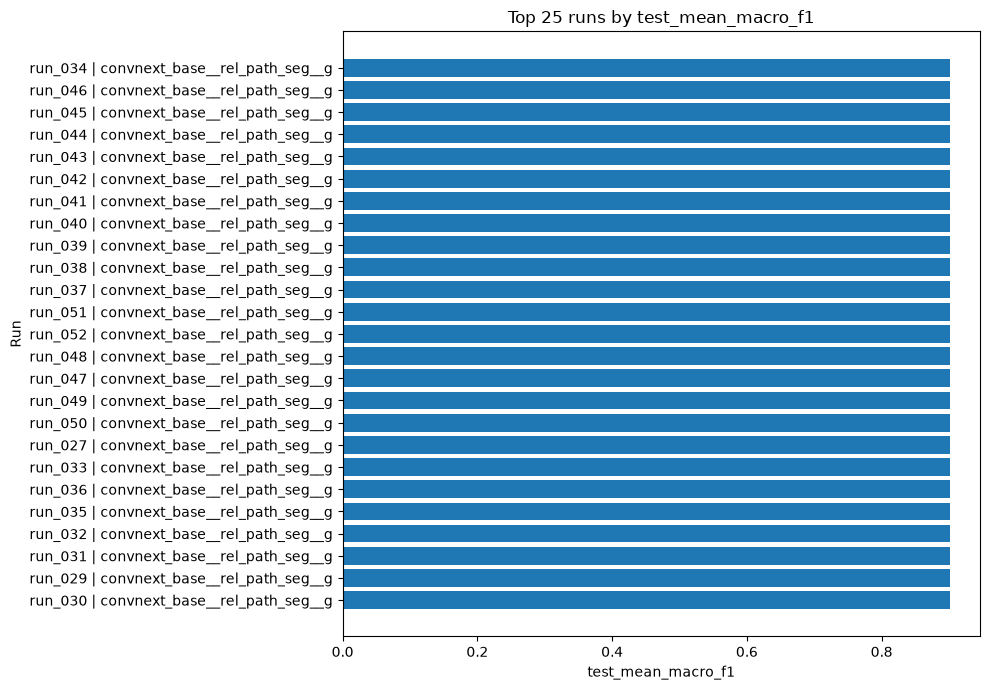

Saved: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_25_runs_by_test_mean_macro_f1.png


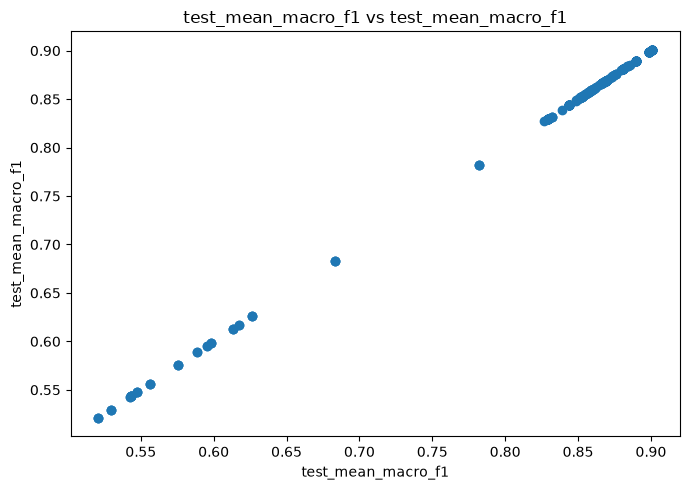

Saved: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/test_mean_macro_f1_vs_test_mean_macro_f1.png


In [24]:
def save_current_fig(name: str) -> Path:
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    return path

# Top-N validation ranking plot.
top_n = min(25, len(ranked))
plot_df = ranked.head(top_n).copy()
plot_df["short_name"] = plot_df["source_run_id"].astype(str) + " | " + plot_df["run_name"].astype(str).str.slice(0, 30)

plt.figure(figsize=(10, max(5, 0.28 * top_n)))
plt.barh(plot_df["short_name"][::-1], plot_df[RANK_BY][::-1])
plt.xlabel(RANK_BY)
plt.ylabel("Run")
plt.title(f"Top {top_n} runs by {RANK_BY}")
path = save_current_fig(f"top_{top_n}_runs_by_{RANK_BY}.png")
plt.show()
print("Saved:", path)

# Validation vs species macro-F1 scatter.
if FOCUS_METRIC in ranked.columns and RANK_BY in ranked.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(ranked[RANK_BY], ranked[FOCUS_METRIC])
    plt.xlabel(RANK_BY)
    plt.ylabel(FOCUS_METRIC)
    plt.title(f"{RANK_BY} vs {FOCUS_METRIC}")
    path = save_current_fig(f"{RANK_BY}_vs_{FOCUS_METRIC}.png")
    plt.show()
    print("Saved:", path)


## 8. Select the best run

By default, this selects the top run according to `RANK_BY`. You can manually override `BEST_DIR` if needed.


In [15]:
valid_ranked = ranked[ranked["has_artifacts"]].copy()

if len(valid_ranked) == 0:
    raise RuntimeError("No ranked rows have resolvable artefact directories.")

best_row = valid_ranked.sort_values(RANK_BY, ascending=False, na_position="last").iloc[0]
BEST_DIR = Path(best_row["artifact_dir"]).resolve()

display(Markdown("### Selected best run"))
display(best_row[summary_cols].to_frame("value"))

print("BEST_DIR =", BEST_DIR)

# Manual override example:
# BEST_DIR = Path("~/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_001/vit_b_16__rel_path_seg__genus__fa46485b").expanduser().resolve()


### Selected best run

,value
rank,1
sweep_id,node_local_sweep_20260706_122839
run_name,convnext_base__rel_path_seg__genus__5ec55a00
source_run_id,run_034
selection_metric,mean_macro_f1
test_mean_macro_f1,0.900932
test_mean_macro_f1,0.900932
test_species_macro_f1,0.908144
test_species_balanced_accuracy,0.901558
test_species_accuracy,0.931889


BEST_DIR = /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00


## 9. Load labels and reports for the best run

The species labels in this project can include genus-level or juvenile/unknown groups such as `Lumbricus_sp` or `Aporrectodea_caliginosa_tuberculata`, so it is important to inspect per-class performance rather than only aggregate accuracy.


In [16]:
def read_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

config = read_json(BEST_DIR / "config.json")
label_to_index_by_task = read_json(BEST_DIR / "label_to_index_by_task.json")
test_metrics = read_json(BEST_DIR / "test_metrics.json")

if test_metrics is not None:
    display(Markdown("### `test_metrics.json`"))
    display(pd.Series(flatten_json_metrics(test_metrics)).to_frame("value"))

if label_to_index_by_task is not None:
    display(Markdown("### Label mappings"))
    for task, mapping in label_to_index_by_task.items():
        display(Markdown(f"#### {task}"))
        tmp = pd.DataFrame(
            [{"label": label, "index": idx} for label, idx in mapping.items()]
        ).sort_values("index")
        display(tmp)


### `test_metrics.json`

,value
loss,0.354495
genus_loss,0.046153
genus_n,1256.000000
genus_accuracy,0.980892
genus_balanced_accuracy,0.985653
genus_macro_f1,0.975764
species_loss,0.441639
species_n,646.000000
species_accuracy,0.931889
species_balanced_accuracy,0.901558


### Label mappings

#### genus

,label,index
0,Allolobophora,0
1,Aporrectodea,1
2,Lumbricus,2


#### species

,label,index
0,Allolobophora_chlorotica,0
1,Aporrectodea_caliginosa,1
2,Aporrectodea_longa,2
3,Aporrectodea_rosea,3
4,Aporrectodea_tuberculata,4
5,Lumbricus_castaneus,5
6,Lumbricus_festivus,6
7,Lumbricus_terrestris_herculeus,7


#### age

,label,index
0,Adult,0
1,Juvenile,1


## 10. Helper functions for classification reports and confusion matrices


In [17]:
def load_confusion_matrix(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)

    if raw.shape[1] >= 2 and str(raw.columns[0]).startswith("Unnamed"):
        cm = raw.set_index(raw.columns[0])
    elif raw.shape[1] == raw.shape[0] + 1:
        cm = raw.set_index(raw.columns[0])
    else:
        cm = raw.copy()
        if cm.shape[0] == cm.shape[1]:
            cm.index = [str(i) for i in range(cm.shape[0])]

    cm = cm.apply(pd.to_numeric, errors="coerce").fillna(0)

    if cm.shape[0] == cm.shape[1] and list(map(str, cm.columns)) != list(map(str, cm.index)):
        if not all(str(c).isdigit() for c in cm.index):
            cm.columns = cm.index

    return cm


def plot_all_confusion_matrices_normalised(
    best_dir: Path,
    out_dir: Path,
    tasks: list[str] = ["species", "genus", "age"],
) -> Path:
    """
    Plot row-normalised confusion matrices for all tasks in one figure.

    Rows = true labels.
    Columns = predicted labels.

    Each non-zero cell shows:
        normalised proportion
        raw count in parentheses
    """
    cms = {}

    for task in tasks:
        cm_path = best_dir / f"confusion_matrix_{task}.csv"

        if not cm_path.exists():
            print(f"Missing confusion matrix for {task}: {cm_path}")
            continue

        counts = load_confusion_matrix(cm_path)
        row_sums = counts.sum(axis=1).replace(0, np.nan)
        norm = counts.div(row_sums, axis=0).fillna(0)

        cms[task] = {
            "counts": counts,
            "norm": norm,
        }

    if not cms:
        raise FileNotFoundError("No confusion matrices were found.")

    n_tasks = len(cms)

    fig, axes = plt.subplots(
        1,
        n_tasks,
        figsize=(max(2 * n_tasks, 12),12),
        constrained_layout=True,
    )

    if n_tasks == 1:
        axes = [axes]

    last_im = None

    for ax, (task, obj) in zip(axes, cms.items()):
        counts = obj["counts"]
        norm = obj["norm"]

        n = norm.shape[0]

        last_im = ax.imshow(norm.values, vmin=0, vmax=1)

        ax.set_title(f"{task}")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))

        ax.set_xticklabels(norm.columns.astype(str), rotation=90, fontsize=8)
        ax.set_yticklabels(norm.index.astype(str), fontsize=8)

        for i in range(n):
            for j in range(n):
                value = norm.iloc[i, j]
                count = int(counts.iloc[i, j])

                if count == 0:
                    text = ""
                else:
                    text = f"{value:.2f}\n({count})"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=7,
                )

    fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.25,
        label="Proportion within true class",
    )

    fig.suptitle("Best run: row-normalised confusion matrices", fontsize=14)

    path = out_dir / "best_run_all_confusion_matrices_normalised_with_counts.png"
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    return path


def find_task_loss_column(history: pd.DataFrame, task: str, split: str = "val") -> str | None:
    cols = list(history.columns)
    task = task.lower()
    split = split.lower()

    exact_candidates = [
        f"{split}_{task}_loss",
        f"{task}_{split}_loss",
        f"{split}_loss_{task}",
        f"{task}_loss_{split}",
    ]

    for candidate in exact_candidates:
        if candidate in cols:
            return candidate

    matching = [
        col for col in cols
        if task in col.lower()
        and "loss" in col.lower()
        and split in col.lower()
    ]

    if matching:
        return matching[0]

    return None


def plot_task_losses(
    best_dir: Path,
    out_dir: Path,
) -> Path | None:
    """
    Plot validation losses for genus, species, and age.

    Validation is only computed every few epochs, so we drop NaN rows
    separately for each task and plot points with markers.
    """
    history_path = best_dir / "history.csv"

    if not history_path.exists():
        print(f"Missing history file: {history_path}")
        return None

    history = pd.read_csv(history_path)

    required_cols = [
        "epoch",
        "val_species_loss",
        "val_genus_loss",
        "val_age_loss",
    ]

    missing_cols = [col for col in required_cols if col not in history.columns]

    if missing_cols:
        print("Missing expected columns:")
        print(missing_cols)
        print("Available columns:")
        print(list(history.columns))
        return None

    loss_cols = {
        "Species validation loss": "val_species_loss",
        "Genus validation loss": "val_genus_loss",
        "Age validation loss": "val_age_loss",
    }

    plt.figure(figsize=(9, 5))

    for label, col in loss_cols.items():
        sub = history[["epoch", col]].dropna()

        if len(sub) == 0:
            print(f"No non-NaN values found for {col}")
            continue

        plt.plot(
            sub["epoch"],
            sub[col],
            marker="o",
            linewidth=1.5,
            label=label,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation loss")
    plt.title("Best run: validation loss by task")
    plt.legend()
    plt.grid(True, alpha=0.3)

    path = out_dir / "best_run_validation_losses_by_task.png"
    plt.tight_layout()
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    return path



In [18]:
import shlex
import textwrap
import re
from pathlib import Path


def read_run_overrides(row: pd.Series) -> tuple[str, Path | None]:
    """
    Read run_overrides.args for a sweep run.

    Expected location:
        <source_run_dir>/run_overrides.args
    """
    candidates = []

    if "source_run_dir" in row and pd.notna(row["source_run_dir"]):
        candidates.append(Path(row["source_run_dir"]) / "run_overrides.args")

    if "artifact_dir" in row and pd.notna(row["artifact_dir"]):
        candidates.append(Path(row["artifact_dir"]).parent / "run_overrides.args")

    for path in candidates:
        if path.exists():
            text = path.read_text().strip()
            return text, path

    return "", None


def compact_overrides_text(
    override_text: str,
    max_chars: int = 260,
) -> str:
    """
    Make run_overrides.args readable inside a plot title/subtitle.

    Works for both:
        key=value key2=value2
    and:
        --key value --key2 value2
    """
    if not override_text:
        return "Parameters: run_overrides.args not found"

    one_line = " ".join(override_text.split())

    # Try to parse shell-style arguments safely.
    try:
        tokens = shlex.split(one_line)
    except ValueError:
        tokens = one_line.split()

    parts = []
    i = 0

    while i < len(tokens):
        tok = tokens[i]

        # Format: --key value
        if tok.startswith("--") and i + 1 < len(tokens) and not tokens[i + 1].startswith("--"):
            key = tok.lstrip("-")
            value = tokens[i + 1]
            parts.append(f"{key}={value}")
            i += 2

        # Format: --key=value
        elif tok.startswith("--") and "=" in tok:
            parts.append(tok.lstrip("-"))
            i += 1

        # Format: key=value
        elif "=" in tok:
            parts.append(tok)
            i += 1

        else:
            parts.append(tok)
            i += 1

    summary = " | ".join(parts)

    if len(summary) > max_chars:
        summary = summary[:max_chars].rstrip() + " ..."

    return f"Parameters: {summary}"


def add_parameter_text_to_figure(
    fig,
    parameter_summary: str,
    y: float = 0.01,
    fontsize: int = 8,
):
    """
    Add wrapped parameter text at the bottom of a matplotlib figure.
    """
    wrapped = textwrap.fill(parameter_summary, width=150)

    fig.text(
        0.5,
        y,
        wrapped,
        ha="center",
        va="bottom",
        fontsize=fontsize,
    )

In [19]:
def plot_all_confusion_matrices_normalised(
    model_dir: Path,
    out_dir: Path,
    tasks: list[str] = ["species", "genus", "age"],
    run_label: str = "",
    parameter_summary: str = "",
) -> Path:
    """
    Plot row-normalised confusion matrices for all tasks in one figure.

    Rows = true labels.
    Columns = predicted labels.

    Each non-zero cell shows:
        normalised proportion
        raw count in parentheses
    """
    cms = {}

    for task in tasks:
        cm_path = model_dir / f"confusion_matrix_{task}.csv"

        if not cm_path.exists():
            print(f"Missing confusion matrix for {task}: {cm_path}")
            continue

        counts = load_confusion_matrix(cm_path)
        row_sums = counts.sum(axis=1).replace(0, np.nan)
        norm = counts.div(row_sums, axis=0).fillna(0)

        cms[task] = {
            "counts": counts,
            "norm": norm,
        }

    if not cms:
        raise FileNotFoundError(f"No confusion matrices were found in {model_dir}")

    n_tasks = len(cms)

    fig, axes = plt.subplots(
        1,
        n_tasks,
        figsize=(max(7 * n_tasks, 12), 7),
        constrained_layout=True,
    )

    if n_tasks == 1:
        axes = [axes]

    last_im = None

    for ax, (task, obj) in zip(axes, cms.items()):
        counts = obj["counts"]
        norm = obj["norm"]

        n = norm.shape[0]

        last_im = ax.imshow(norm.values, vmin=0, vmax=1)

        ax.set_title(task)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))

        ax.set_xticklabels(norm.columns.astype(str), rotation=90, fontsize=8)
        ax.set_yticklabels(norm.index.astype(str), fontsize=8)

        for i in range(n):
            for j in range(n):
                value = norm.iloc[i, j]
                count = int(counts.iloc[i, j])

                if count == 0:
                    text = ""
                else:
                    text = f"{value:.2f}\n({count})"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black" if value > 0.5 else "white",
                    fontweight="bold" if value < 0.5 else "normal"
                )

    fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.045,
        pad=0.04,
        label="Proportion within true class",
    )

    if run_label:
        fig.suptitle(f"{run_label}: row-normalised confusion matrices", fontsize=14)
    else:
        fig.suptitle("Row-normalised confusion matrices", fontsize=14)

    if parameter_summary:
        add_parameter_text_to_figure(fig, parameter_summary, y=0.01, fontsize=8)

    path = out_dir / "confusion_matrices_normalised_with_counts.png"
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    return path

In [20]:
def plot_task_losses(
    model_dir: Path,
    out_dir: Path,
    run_label: str = "",
    parameter_summary: str = "",
) -> Path | None:
    """
    Plot validation losses for genus, species, and age.

    Validation happens only every few epochs, so NaN rows are dropped
    separately for each task.
    """
    history_path = model_dir / "history.csv"

    if not history_path.exists():
        print(f"Missing history file: {history_path}")
        return None

    history = pd.read_csv(history_path)

    required_cols = [
        "epoch",
        "train_loss",
        "val_loss",
        "val_species_loss",
        "val_genus_loss",
        "val_age_loss",
    ]

    missing_cols = [col for col in required_cols if col not in history.columns]

    if missing_cols:
        print(f"Missing expected columns in {history_path}:")
        print(missing_cols)
        return None

    plt.figure(figsize=(10, 5))

    train_sub = history[["epoch", "train_loss"]].dropna()
    plt.plot(
        train_sub["epoch"],
        train_sub["train_loss"],
        linewidth=1.5,
        label="Total training loss",
    )

    val_cols = {
        "Total validation loss": "val_loss",
        "Species validation loss": "val_species_loss",
        "Genus validation loss": "val_genus_loss",
        "Age validation loss": "val_age_loss",
    }

    for label, col in val_cols.items():
        sub = history[["epoch", col]].dropna()

        if len(sub) == 0:
            print(f"No non-NaN values found for {col}")
            continue

        plt.plot(
            sub["epoch"],
            sub[col],
            marker="o",
            linewidth=1.5,
            label=label,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    if run_label:
        plt.title(f"{run_label}: training and validation losses")
    else:
        plt.title("Training and validation losses")

    plt.legend()
    plt.grid(True, alpha=0.3)

    fig = plt.gcf()

    if parameter_summary:
        add_parameter_text_to_figure(fig, parameter_summary, y=0.01, fontsize=8)

    path = out_dir / "training_and_validation_losses.png"
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()

    return path

In [30]:
ranked

,run_name,out_dir,best_val_score,selection_metric,test_loss,test_genus_loss,test_genus_n,test_genus_accuracy,test_genus_balanced_accuracy,test_genus_macro_f1,test_species_loss,test_species_n,test_species_accuracy,test_species_balanced_accuracy,test_species_macro_f1,test_age_loss,test_age_n,test_age_accuracy,test_age_balanced_accuracy,test_age_macro_f1,test_mean_macro_f1,test_complete_exact_match_accuracy,test_complete_exact_match_n,source_csv,source_run_dir,source_run_id,sweep_dir,sweep_id,artifact_dir,has_artifacts,json__loss,json__genus_loss,json__genus_n,json__genus_accuracy,json__genus_balanced_accuracy,json__genus_macro_f1,json__species_loss,json__species_n,json__species_accuracy,json__species_balanced_accuracy,json__species_macro_f1,json__age_loss,json__age_n,json__age_accuracy,json__age_balanced_accuracy,json__age_macro_f1,json__mean_macro_f1,json__complete_exact_match_accuracy,json__complete_exact_match_n,rank
0,convnext_base__rel_path_seg__genus__5ec55a00,/scratch/mehrot/worm_node_local_sweep_20260706_122839_1435801/outputs/run_034/convnext_base__rel_path_seg__genus__5ec55a00,0.868806,mean_macro_f1,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034,run_034,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839,node_local_sweep_20260706_122839,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00,True,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,1
1,convnext_base__rel_path_seg__genus__9819ad4e,/scratch/mehrot/worm_node_local_sweep_20260706_122839_1435801/outputs/run_046/convnext_base__rel_path_seg__genus__9819ad4e,0.868806,mean_macro_f1,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046,run_046,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839,node_local_sweep_20260706_122839,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046/convnext_base__rel_path_seg__genus__9819ad4e,True,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,2
2,convnext_base__rel_path_seg__genus__cee1e9a7,/scratch/mehrot/worm_node_local_sweep_20260706_122839_1435801/outputs/run_045/convnext_base__rel_path_seg__genus__cee1e9a7,0.868806,mean_macro_f1,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045/multi_run_results.csv,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045,run_045,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839,node_local_sweep_20260706_122839,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045/convnext_base__rel_path_seg__genus__cee1e9a7,True,0.354495,0.046153,1256,0.980892,0.985653,0.975764,0.441639,646,0.931889,0.901558,0.908144,0.575692,1256,0.847134,0.836178,0.818890,0.900932,0.769350,646,3
3,convnext_base__rel_path_seg__genus__17fe2242,/scratch/mehrot/worm_node_local_sweep_20260706_122839_1435801/outputs/run_044/convnext_base__rel_path_seg__genus__17fe2242,0.868806,mea

Rank 1 | convnext_base__rel_path_seg__genus__5ec55a00 | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=1.0 | multitask.loss_weights.species=2.0 | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_01_convnext_base__rel_path_seg__genus__5ec55a00


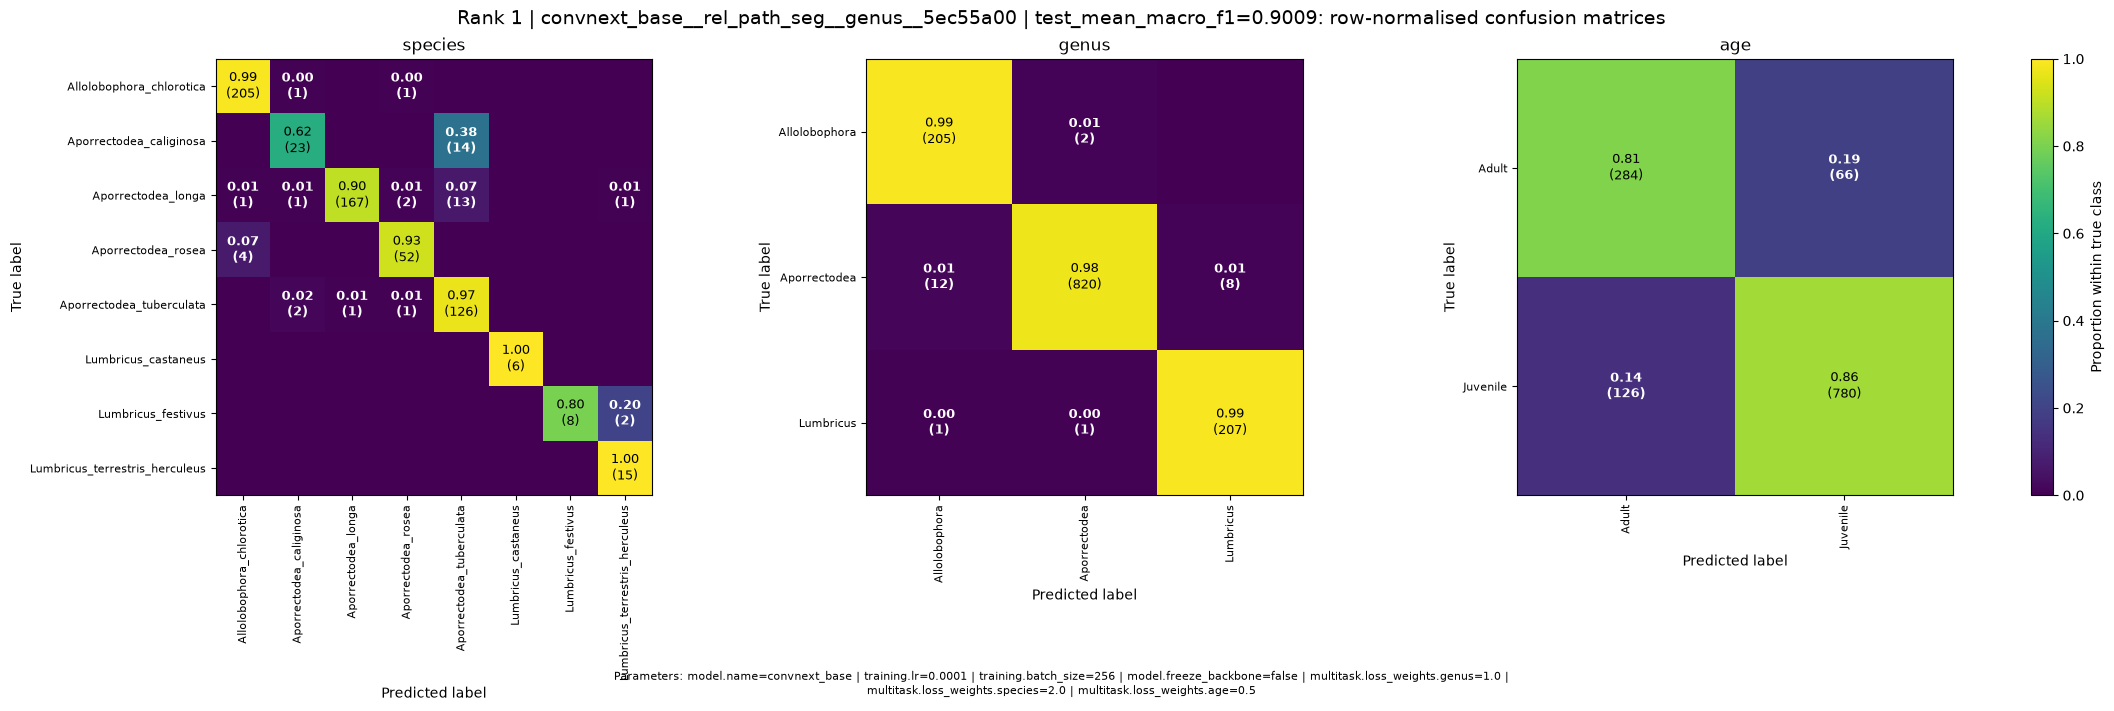

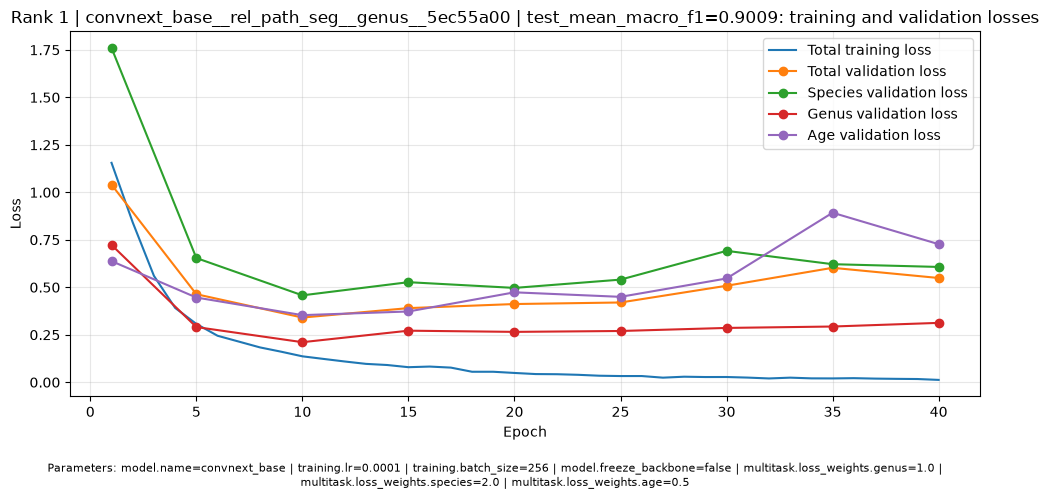

Rank 2 | convnext_base__rel_path_seg__genus__9819ad4e | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=2.0 | multitask.loss_weights.species=1.0 | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_046/convnext_base__rel_path_seg__genus__9819ad4e
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_02_convnext_base__rel_path_seg__genus__9819ad4e


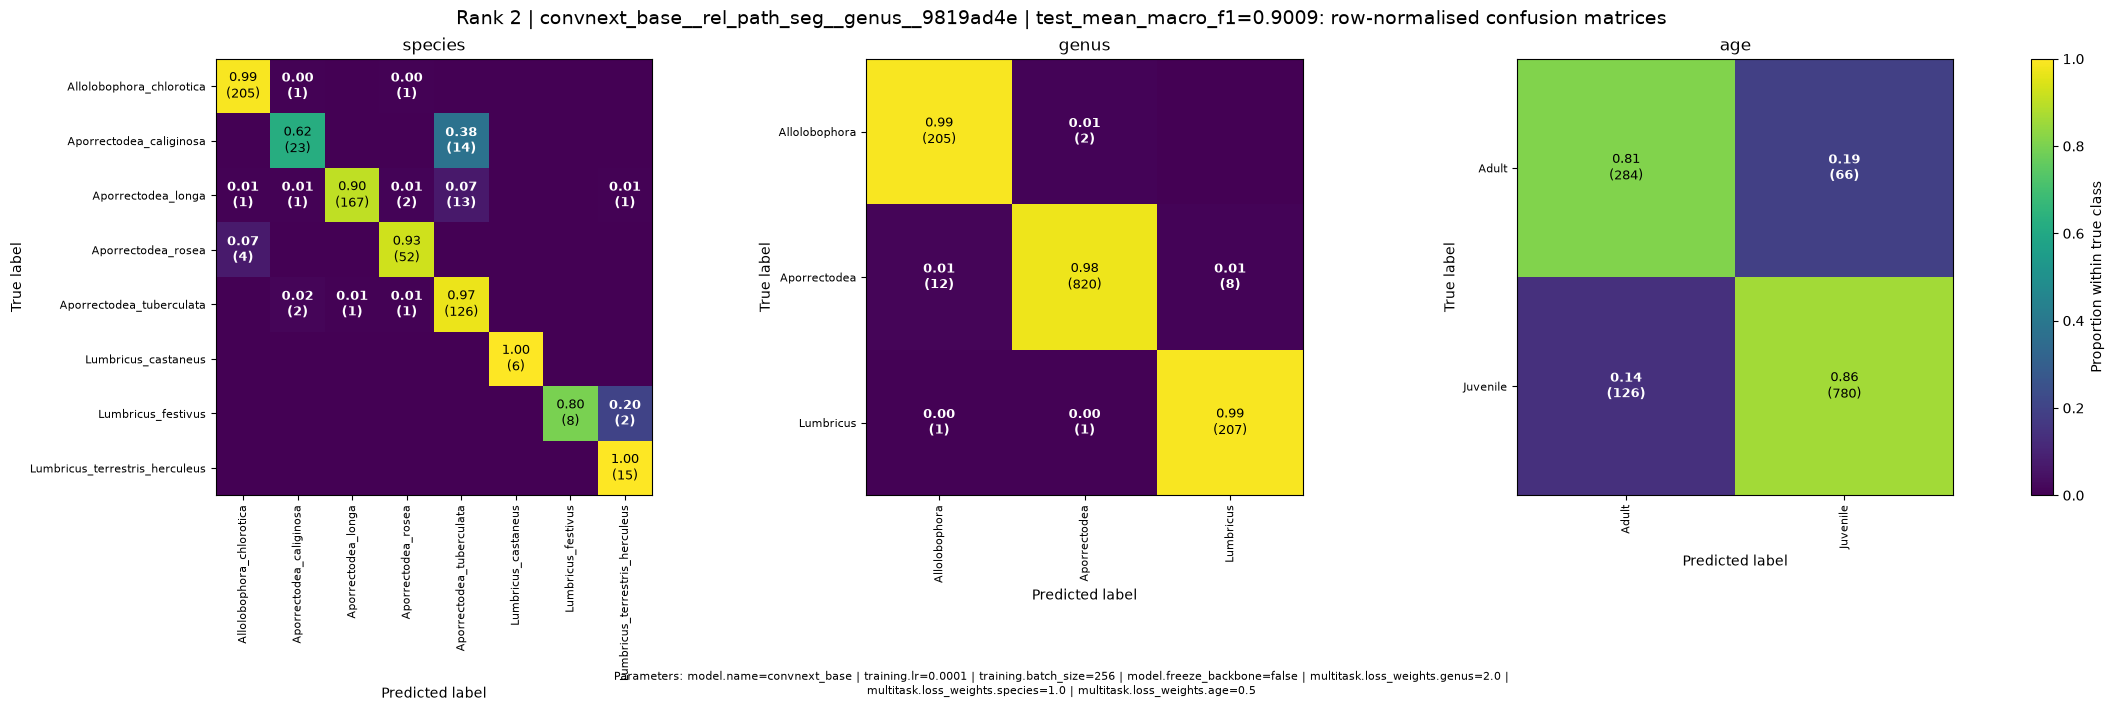

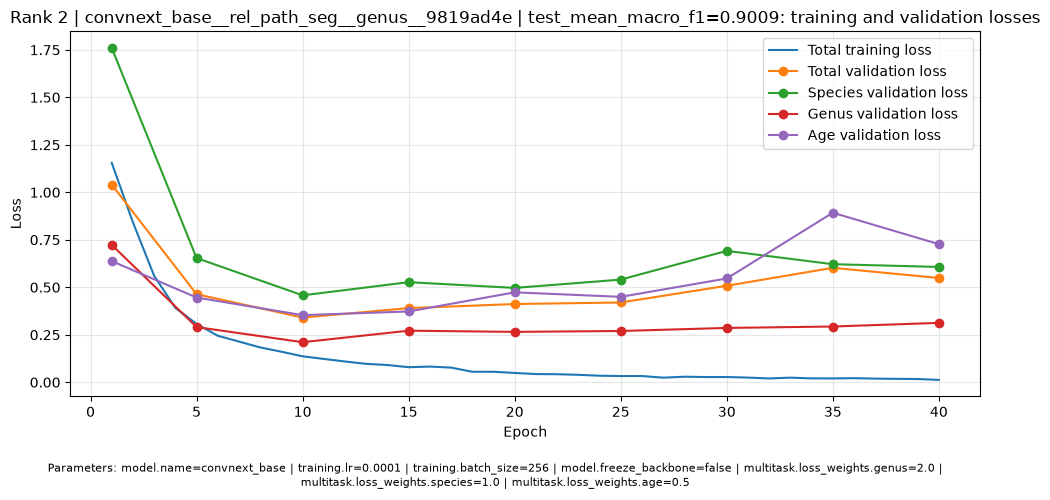

Rank 3 | convnext_base__rel_path_seg__genus__cee1e9a7 | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=2.0 | multitask.loss_weights.species=1.0 | multitask.loss_weights.age=1.0
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_045/convnext_base__rel_path_seg__genus__cee1e9a7
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_03_convnext_base__rel_path_seg__genus__cee1e9a7


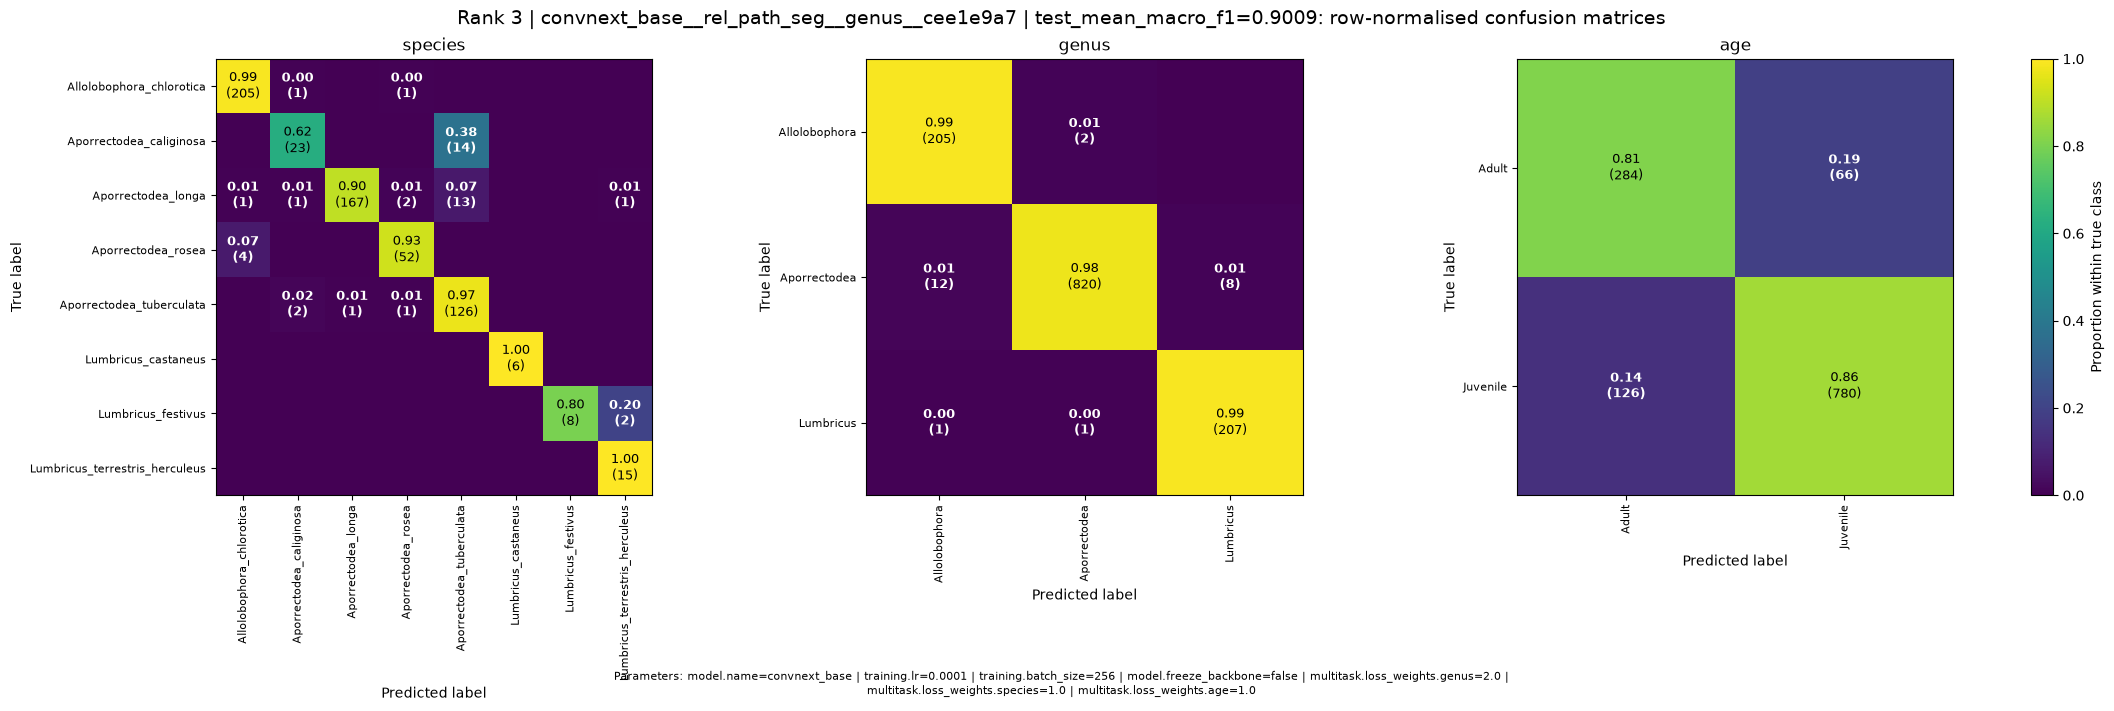

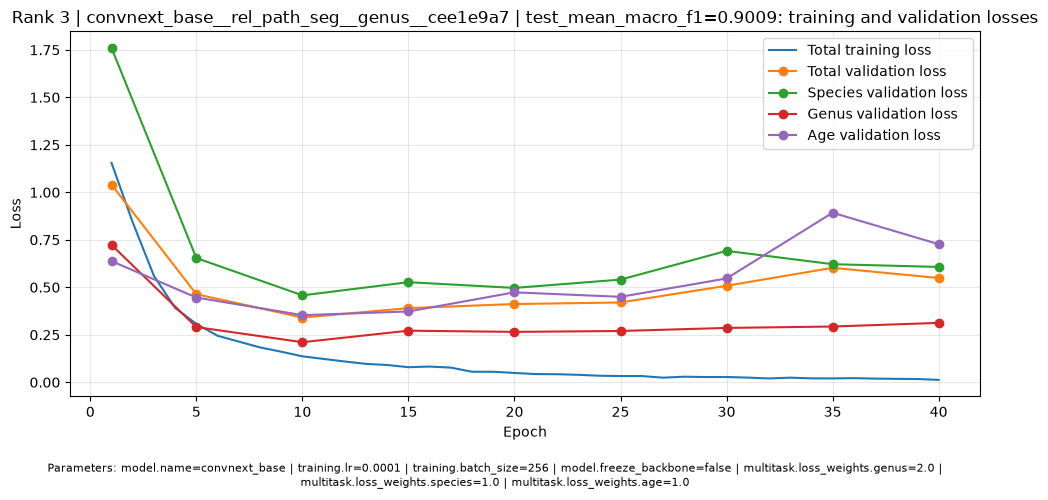

Rank 4 | convnext_base__rel_path_seg__genus__17fe2242 | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=0.5 | multitask.loss_weights.species=2.0 | multitask.loss_weights.age=2.0
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_044/convnext_base__rel_path_seg__genus__17fe2242
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_04_convnext_base__rel_path_seg__genus__17fe2242


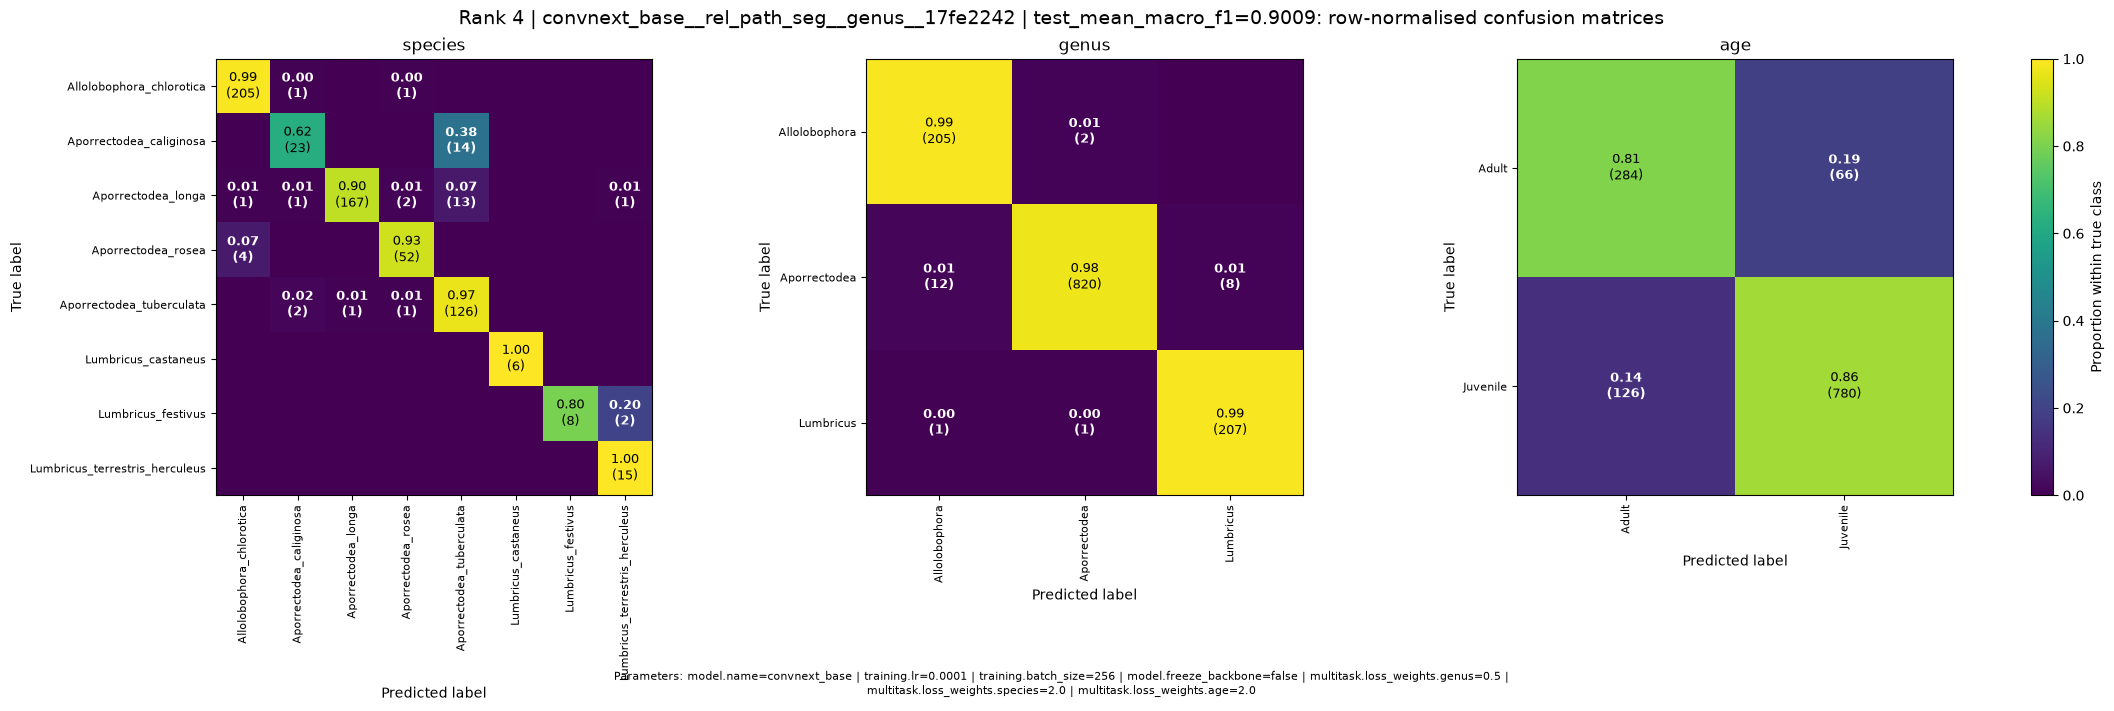

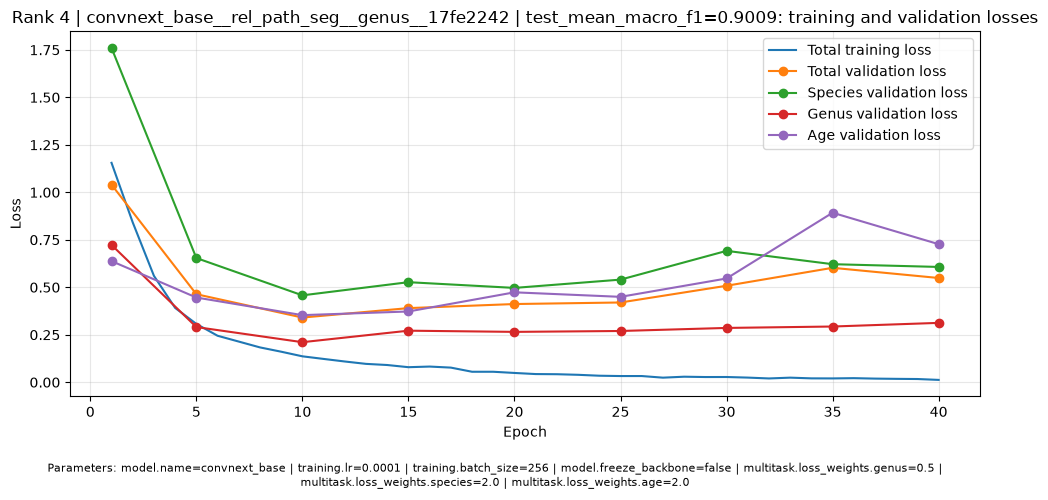

Rank 5 | convnext_base__rel_path_seg__genus__d90b6a47 | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=0.5 | multitask.loss_weights.species=2.0 | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_043/convnext_base__rel_path_seg__genus__d90b6a47
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_05_convnext_base__rel_path_seg__genus__d90b6a47


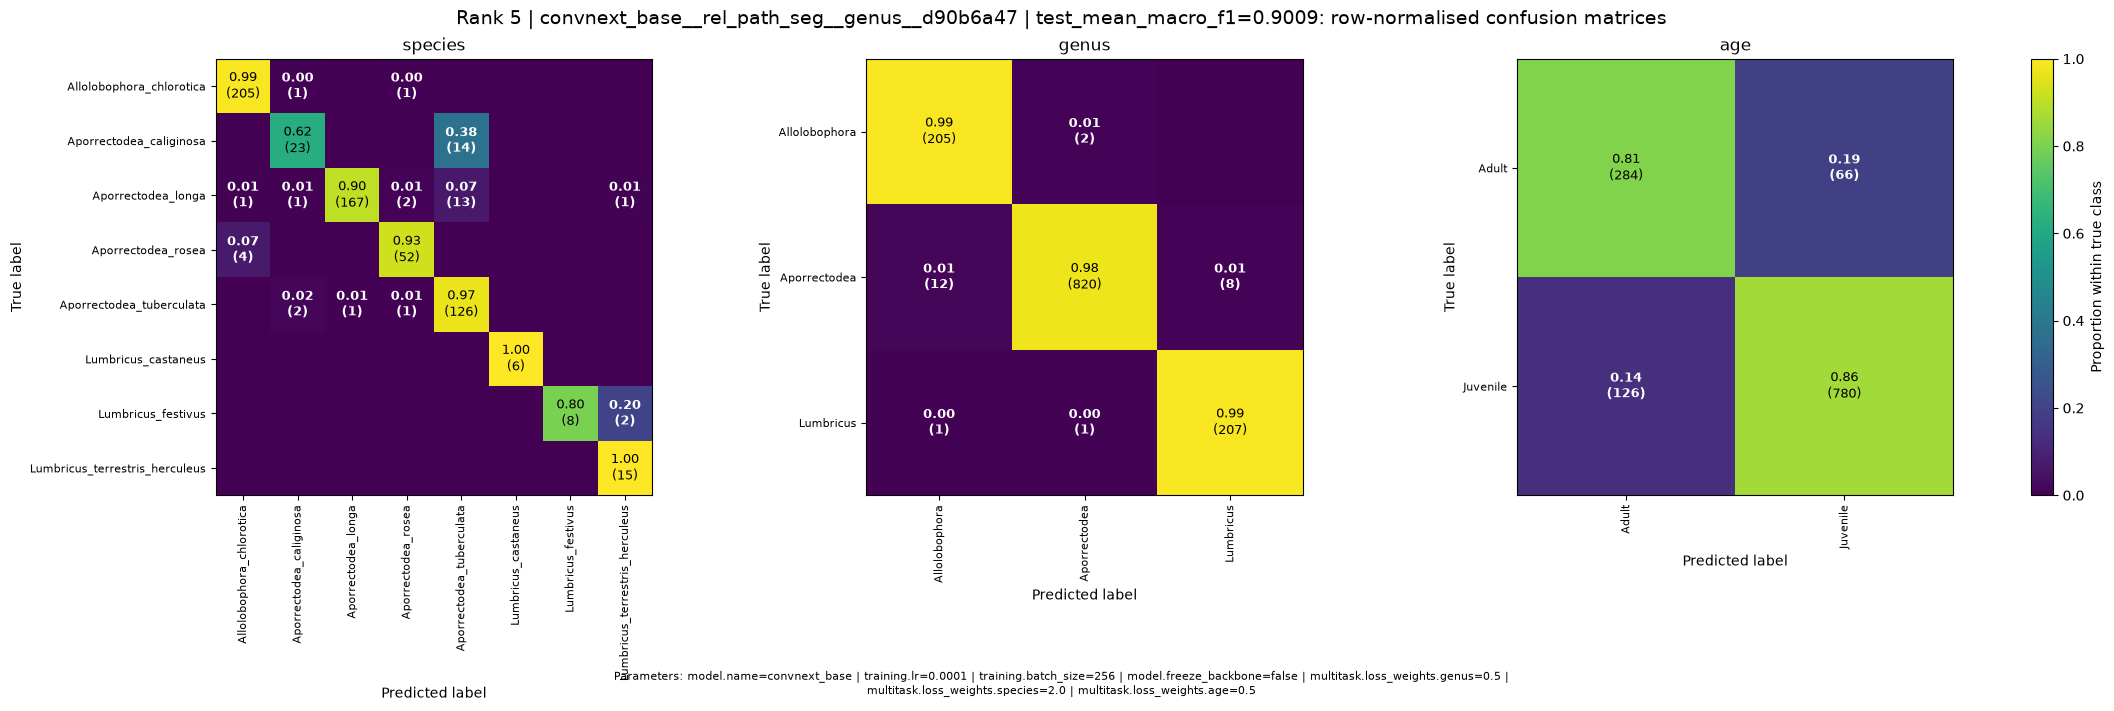

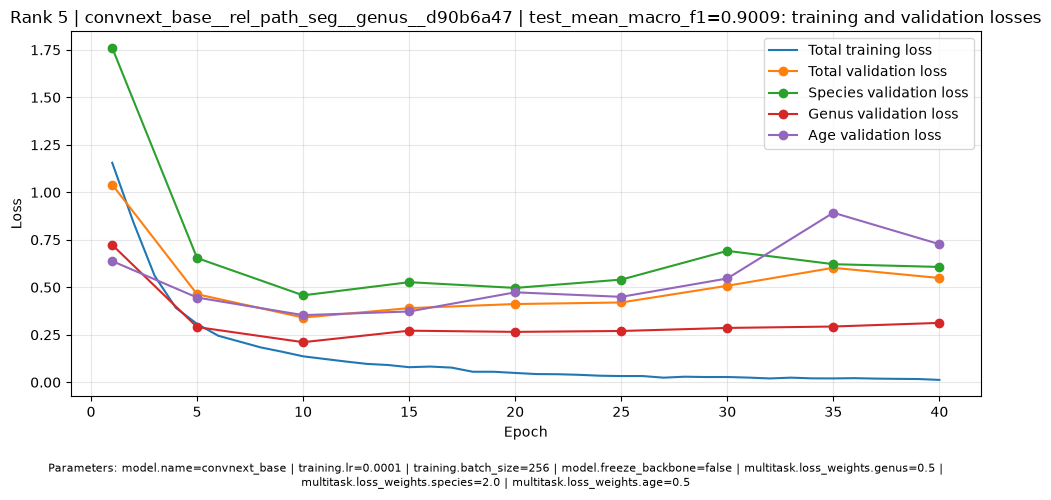

\nSaved plots:
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_01_convnext_base__rel_path_seg__genus__5ec55a00/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_01_convnext_base__rel_path_seg__genus__5ec55a00/training_and_validation_losses.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_02_convnext_base__rel_path_seg__genus__9819ad4e/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_02_convnext_base__rel_path_seg__genus__9819ad4e/training_and_validation_losses.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_5_run_plots/rank_03_convnext_base__rel_path_seg__genus__cee1e9a7/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/

In [29]:
import re

def safe_slug(text: str, max_len: int = 80) -> str:
    """
    Convert a run name or parameter string into a safe folder/file name.
    """
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_.-]+", "_", text)
    text = text.strip("_")

    if len(text) > max_len:
        text = text[:max_len].rstrip("_")

    return text

TOP_K = 5

top_runs = (
    ranked[ranked["has_artifacts"]]
    .sort_values(RANK_BY, ascending=False, na_position="last")
    .head(TOP_K)
    .copy()
)

TOP_ANALYSIS_FIGURE_DIR = FIGURE_DIR / f"top_{TOP_K}_run_plots"
TOP_ANALYSIS_TABLE_DIR = TABLE_DIR / f"top_{TOP_K}_run_plots"
TOP_ANALYSIS_FIGURE_DIR.mkdir(exist_ok=True)
TOP_ANALYSIS_TABLE_DIR.mkdir(exist_ok=True)

all_saved_paths = []

for i, (_, row) in enumerate(top_runs.iterrows(), start=1):
    model_dir = Path(row["artifact_dir"]).resolve()
    run_name = row["run_name"]
    score = row[RANK_BY]

    override_text, override_path = read_run_overrides(row)
    parameter_summary = compact_overrides_text(override_text)

    run_label = f"Rank {i} | {run_name} | {RANK_BY}={score:.4f}"

    run_figure_dir = TOP_ANALYSIS_FIGURE_DIR / f"rank_{i:02d}_{safe_slug(run_name)}"
    run_table_dir = TOP_ANALYSIS_TABLE_DIR / f"rank_{i:02d}_{safe_slug(run_name)}"
    run_figure_dir.mkdir(exist_ok=True)
    run_table_dir.mkdir(exist_ok=True)

    # Save full parameters separately, because plot titles should stay readable.
    params_out = run_table_dir / "run_overrides.args"
    params_out.write_text(override_text if override_text else "run_overrides.args not found")

    summary_out = run_table_dir / "run_summary.txt"
    summary_out.write_text(
        "\\n".join(
            [
                run_label,
                f"Model directory: {model_dir}",
                f"Override file: {override_path if override_path is not None else 'not found'}",
                "",
                "Compact parameter summary:",
                parameter_summary,
                "",
                "Full run_overrides.args:",
                override_text if override_text else "not found",
            ]
        )
    )

    print("=" * 100)
    print(run_label)
    print(parameter_summary)
    print("Model directory:", model_dir)
    print("Figure directory:", run_figure_dir)
    print("Table directory:", run_table_dir)

    cm_path = plot_all_confusion_matrices_normalised(
        model_dir=model_dir,
        out_dir=run_figure_dir,
        tasks=TASKS,
        run_label=run_label,
        parameter_summary=parameter_summary,
    )
    all_saved_paths.append(cm_path)

    loss_path = plot_task_losses(
        model_dir=model_dir,
        out_dir=run_figure_dir,
        run_label=run_label,
        parameter_summary=parameter_summary,
    )

    if loss_path is not None:
        all_saved_paths.append(loss_path)


print("\\nSaved plots:")
for path in all_saved_paths:
    print(path)

In [31]:
import json
import shlex
from pathlib import Path


def parse_overrides_to_dict(override_text: str) -> dict[str, str]:
    """
    Parse run_overrides.args into a dictionary.

    Supports:
        model.name=vit_b_16 training.lr=0.0001
    and:
        --model.name vit_b_16 --training.lr 0.0001
    and:
        --model.name=vit_b_16
    """
    if not override_text:
        return {}

    try:
        tokens = shlex.split(" ".join(override_text.split()))
    except ValueError:
        tokens = override_text.split()

    out = {}
    i = 0

    while i < len(tokens):
        tok = tokens[i]

        if tok.startswith("--") and "=" in tok:
            key, value = tok.lstrip("-").split("=", 1)
            out[key] = value
            i += 1

        elif tok.startswith("--") and i + 1 < len(tokens):
            key = tok.lstrip("-")
            value = tokens[i + 1]
            out[key] = value
            i += 2

        elif "=" in tok:
            key, value = tok.split("=", 1)
            out[key] = value
            i += 1

        else:
            i += 1

    return out


def model_type_from_config(row: pd.Series) -> str | None:
    """
    Try to read model.name from the saved config.json.
    """
    if "artifact_dir" not in row or pd.isna(row["artifact_dir"]):
        return None

    config_path = Path(row["artifact_dir"]) / "config.json"

    if not config_path.exists():
        return None

    try:
        with open(config_path, "r") as f:
            cfg = json.load(f)

        return cfg.get("model", {}).get("name")

    except Exception:
        return None


def infer_model_type(row: pd.Series) -> str:
    """
    Infer model type from:
    1. run_overrides.args
    2. config.json
    3. run_name prefix before '__'
    """
    override_text, _ = read_run_overrides(row)
    override_dict = parse_overrides_to_dict(override_text)

    if "model.name" in override_dict:
        return str(override_dict["model.name"])

    from_config = model_type_from_config(row)

    if from_config is not None:
        return str(from_config)

    run_name = str(row.get("run_name", ""))

    if "__" in run_name:
        return run_name.split("__")[0]

    return "unknown_model"


ranked = ranked.copy()
ranked["model_type"] = ranked.apply(infer_model_type, axis=1)

display(
    ranked
    .groupby("model_type")
    .size()
    .reset_index(name="n_runs")
    .sort_values("n_runs", ascending=False)
)

,model_type,n_runs
3,resnet18,67
2,efficientnet_b1,66
4,resnet50,66
5,vit_b_16,63
0,convnext_base,52
1,efficientnet_b0,17


In [32]:
top_by_model = (
    ranked[ranked["has_artifacts"]]
    .sort_values(RANK_BY, ascending=False, na_position="last")
    .groupby("model_type", as_index=False)
    .head(1)
    .sort_values(RANK_BY, ascending=False)
    .reset_index(drop=True)
)

top_by_model["model_rank"] = np.arange(1, len(top_by_model) + 1)

model_summary_cols = [
    "model_rank",
    "model_type",
    "sweep_id",
    "run_name",
    "source_run_id",
    RANK_BY,
    "test_mean_macro_f1",
    "test_species_macro_f1",
    "test_species_balanced_accuracy",
    "test_species_accuracy",
    "test_genus_macro_f1",
    "test_age_macro_f1",
    "artifact_dir",
]

model_summary_cols = [c for c in model_summary_cols if c in top_by_model.columns]

display(top_by_model[model_summary_cols])

TOP_BY_MODEL_FIGURE_DIR = FIGURE_DIR / "top_run_per_model_type"
TOP_BY_MODEL_TABLE_DIR = TABLE_DIR / "top_run_per_model_type"
TOP_BY_MODEL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TOP_BY_MODEL_TABLE_DIR.mkdir(parents=True, exist_ok=True)

top_by_model_csv = TOP_BY_MODEL_TABLE_DIR / f"top_run_per_model_type_by_{RANK_BY}.csv"
top_by_model[model_summary_cols].to_csv(top_by_model_csv, index=False)

print("Saved:", top_by_model_csv)

,model_rank,model_type,sweep_id,run_name,source_run_id,test_mean_macro_f1,test_mean_macro_f1,test_species_macro_f1,test_species_balanced_accuracy,test_species_accuracy,test_genus_macro_f1,test_age_macro_f1,artifact_dir
0,1,convnext_base,node_local_sweep_20260706_122839,convnext_base__rel_path_seg__genus__5ec55a00,run_034,0.900932,0.900932,0.908144,0.901558,0.931889,0.975764,0.818890,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00
1,2,vit_b_16,node_local_sweep_20260706_122839,vit_b_16__rel_path_seg__genus__b63b4a48,run_145,0.898461,0.898461,0.894019,0.890075,0.919505,0.976783,0.824580,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_145/vit_b_16__rel_path_seg__genus__b63b4a48
2,3,resnet18,node_local_sweep_20260706_122839,resnet18__rel_path_seg__genus__68d3b62a,run_179,0.885542,0.885542,0.867201,0.883449,0.902477,0.967534,0.821892,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_179/resnet18__rel_path_seg__genus__68d3b62a
3,4,efficientnet_b1,node_local_sweep_20260706_122839,efficientnet_b1__rel_path_seg__genus__c29eb941,run_300,0.881059,0.881059,0.863313,0.879597,0.883901,0.961694,0.818171,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_300/efficientnet_b1__rel_path_seg__genus__c29eb941
4,5,efficientnet_b0,node_local_sweep_20260703_164317,efficientnet_b0__rel_path_seg__genus__e84ef6e5,run_031,0.876219,0.876219,0.869487,0.888532,0.902477,0.951159,0.808012,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_031/efficientnet_b0__rel_path_seg__genus__e84ef6e5
5,6,resnet50,node_local_sweep_20260703_164317,resnet50__rel_path_seg__genus__a72c4d66,run_084,0.869064,0.869064,0.845989,0.841469,0.880805,0.963016,0.798188,/usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_084/resnet50__rel_path_seg__genus__a72c4d66


Saved: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/top_run_per_model_type_by_test_mean_macro_f1.csv


Best convnext_base | node_local_sweep_20260706_122839 | convnext_base__rel_path_seg__genus__5ec55a00 | test_mean_macro_f1=0.9009
Parameters: model.name=convnext_base | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=1.0 | multitask.loss_weights.species=2.0 | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/convnext_base__convnext_base__rel_path_seg__genus__5ec55a00


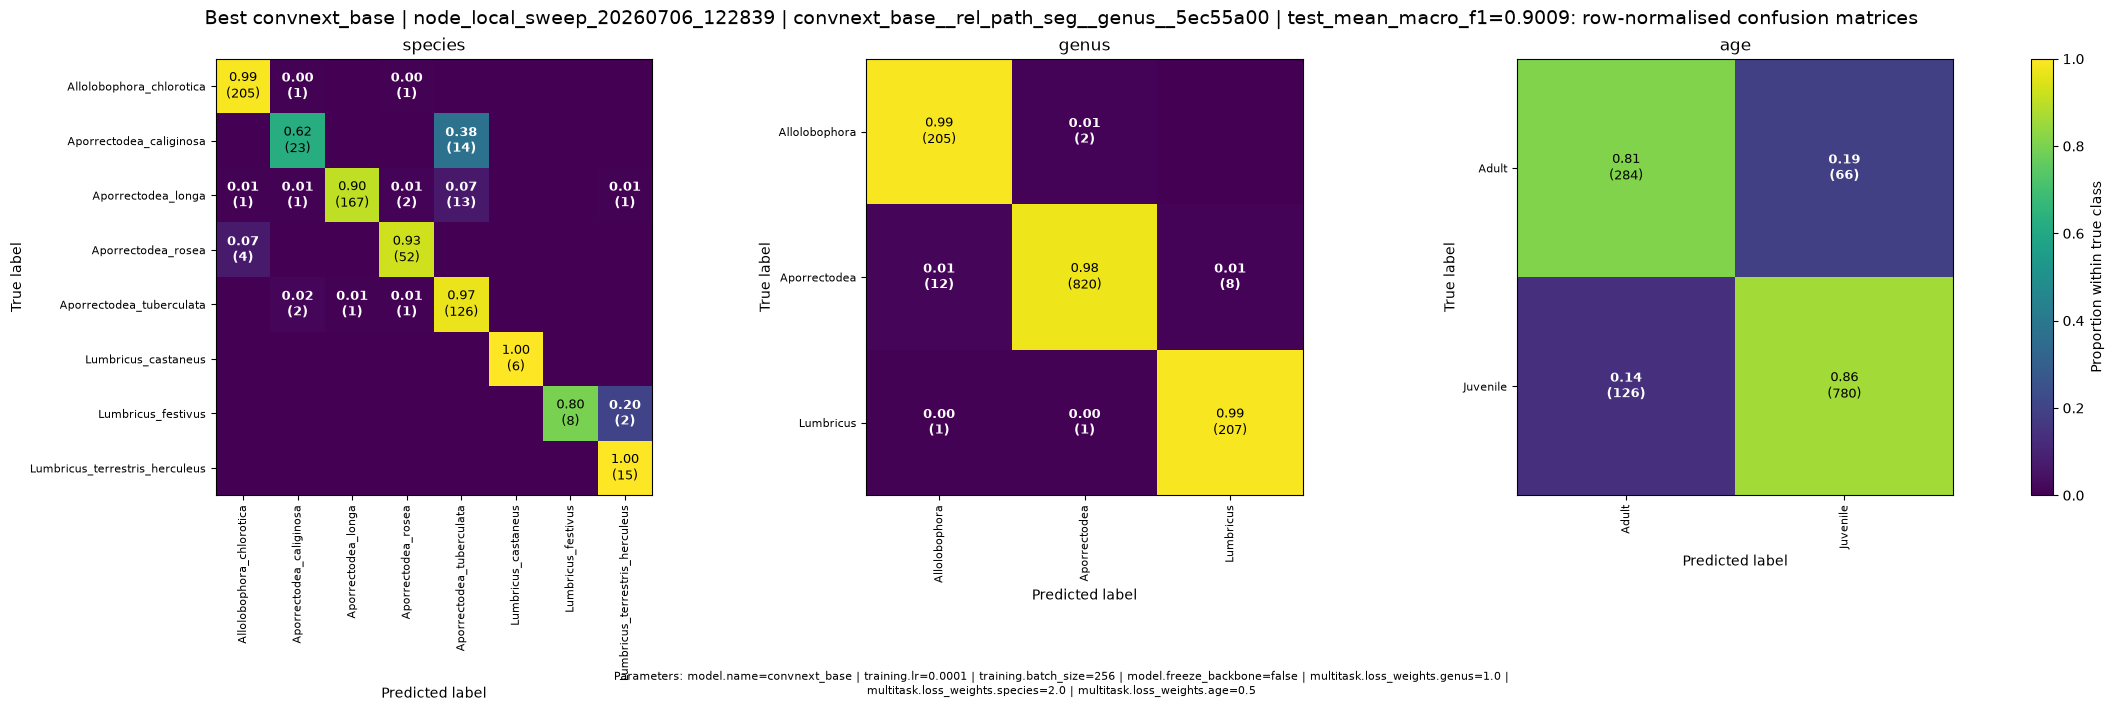

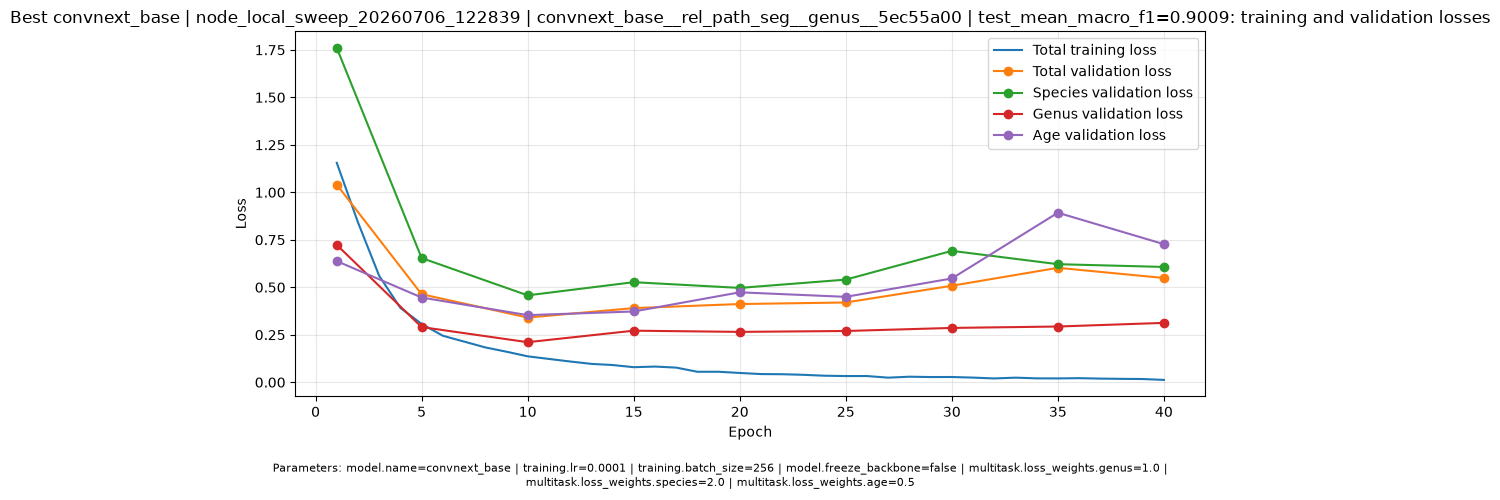

Best vit_b_16 | node_local_sweep_20260706_122839 | vit_b_16__rel_path_seg__genus__b63b4a48 | test_mean_macro_f1=0.8985
Parameters: model.name=vit_b_16 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=0.5 | multitask.loss_weights.species=1.0 | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_145/vit_b_16__rel_path_seg__genus__b63b4a48
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/vit_b_16__vit_b_16__rel_path_seg__genus__b63b4a48


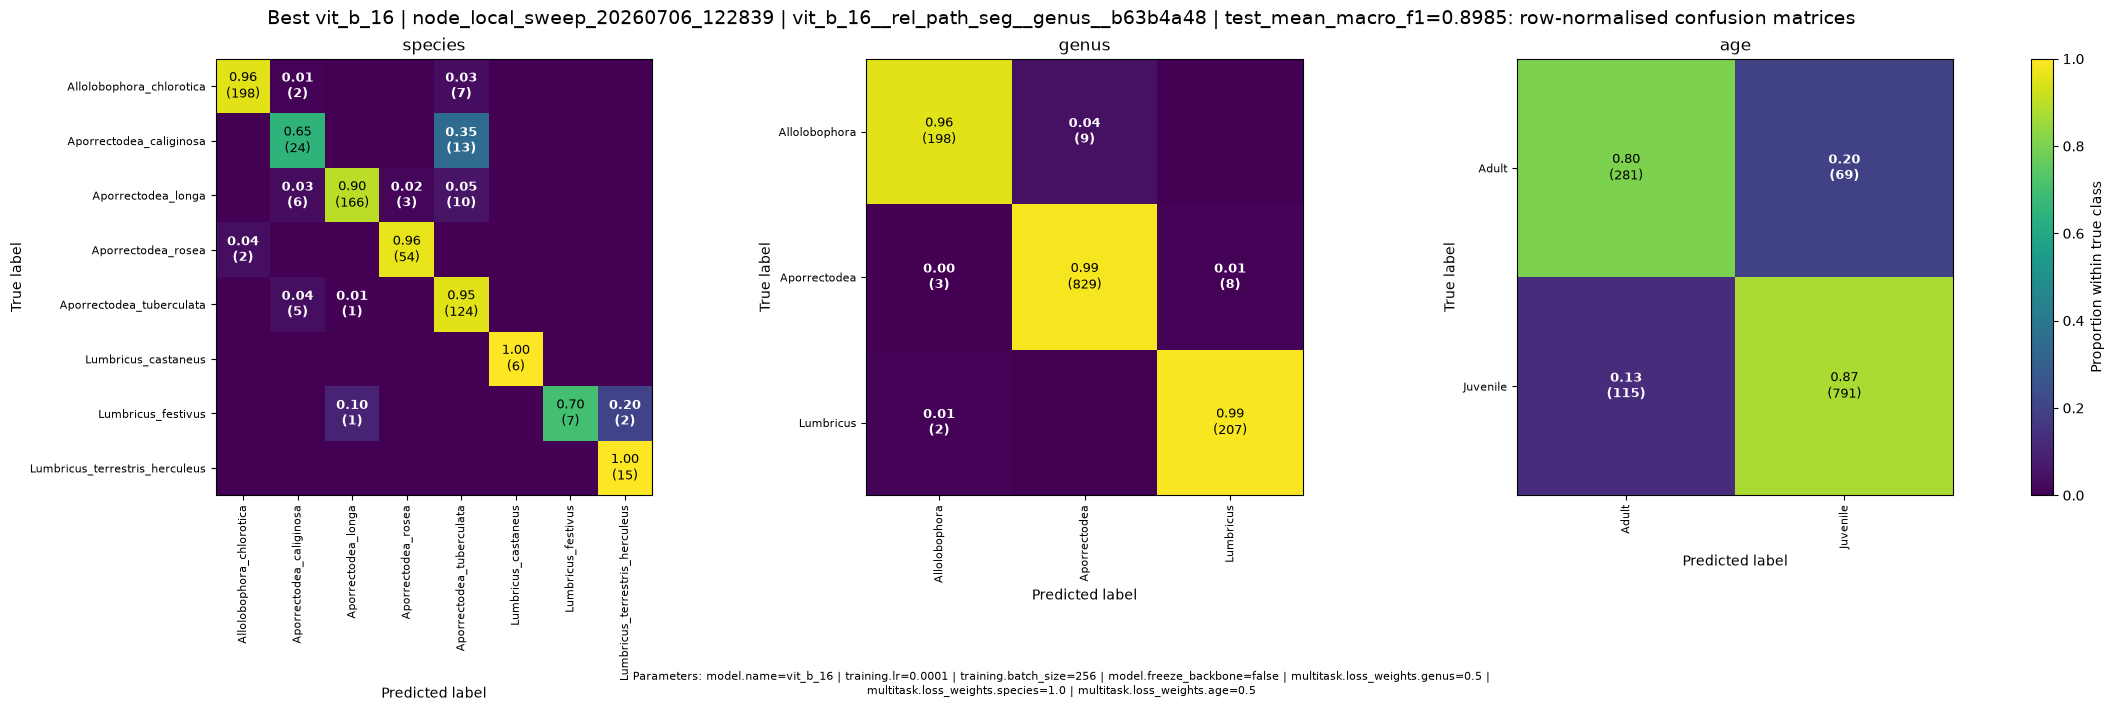

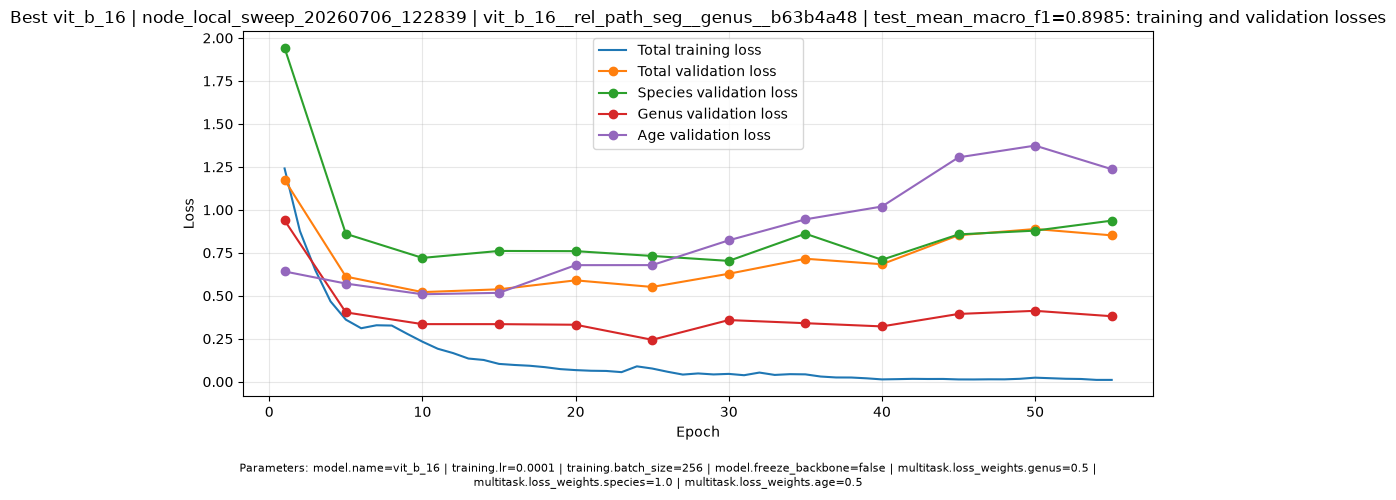

Best resnet18 | node_local_sweep_20260706_122839 | resnet18__rel_path_seg__genus__68d3b62a | test_mean_macro_f1=0.8855
Parameters: model.name=resnet18 | training.lr=0.0003 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=0.5 | multitask.loss_weights.species=2.0 | multitask.loss_weights.age=2.0
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_179/resnet18__rel_path_seg__genus__68d3b62a
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/resnet18__resnet18__rel_path_seg__genus__68d3b62a


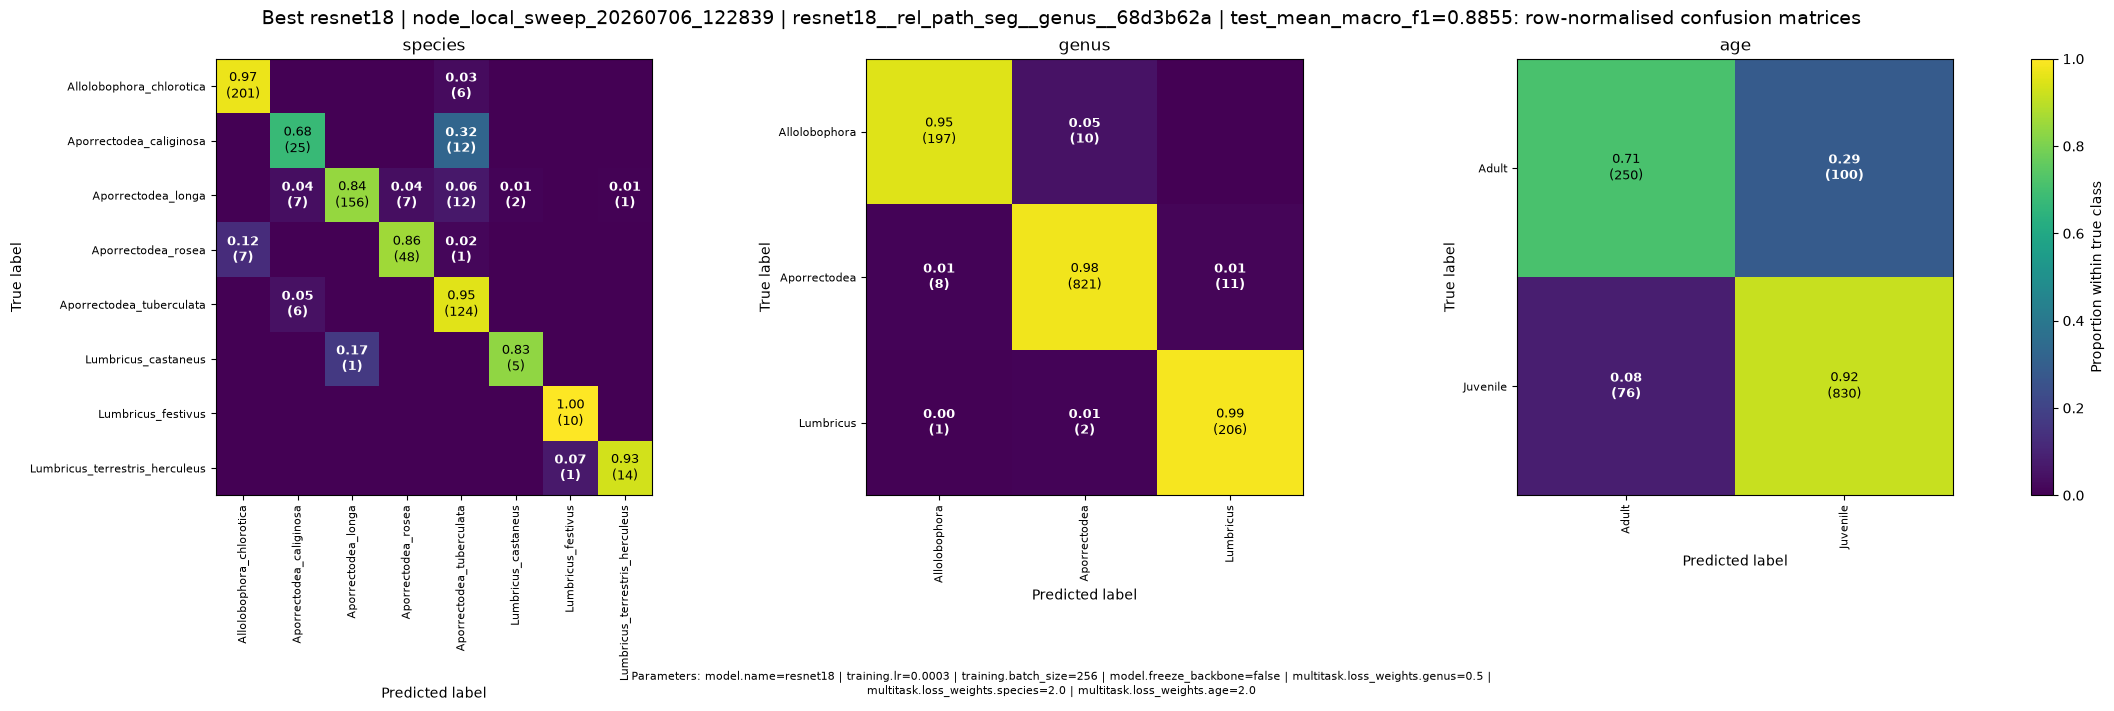

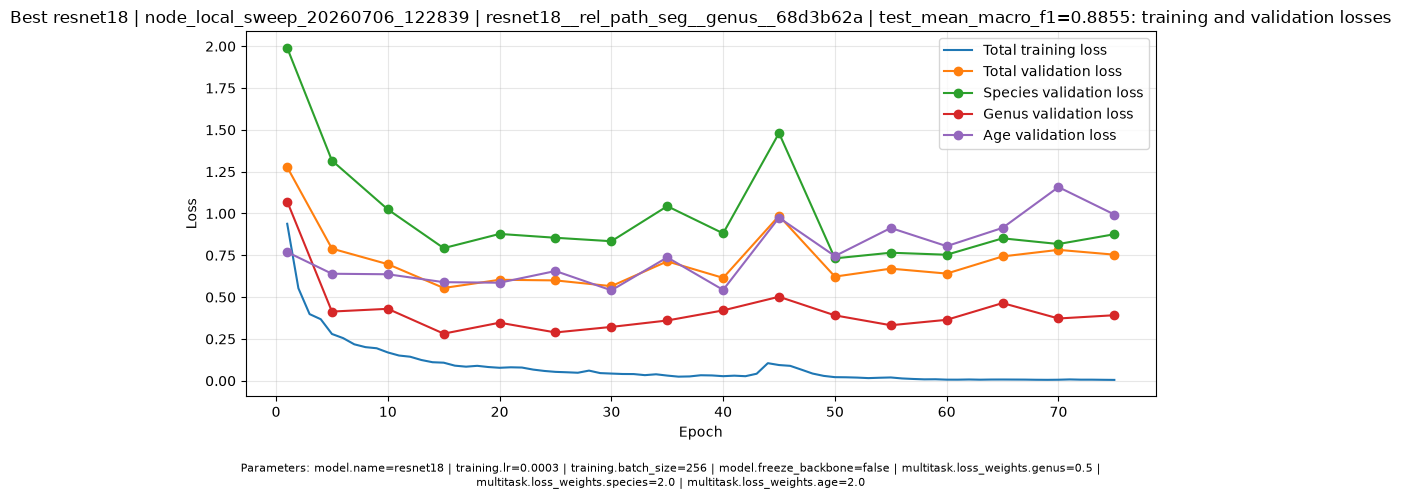

Best efficientnet_b1 | node_local_sweep_20260706_122839 | efficientnet_b1__rel_path_seg__genus__c29eb941 | test_mean_macro_f1=0.8811
Parameters: model.name=efficientnet_b1 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.genus=1.0 | multitask.loss_weights.species=0.5 | multitask.loss_weights.age=1.0
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260706_122839/run_300/efficientnet_b1__rel_path_seg__genus__c29eb941
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/efficientnet_b1__efficientnet_b1__rel_path_seg__genus__c29eb941


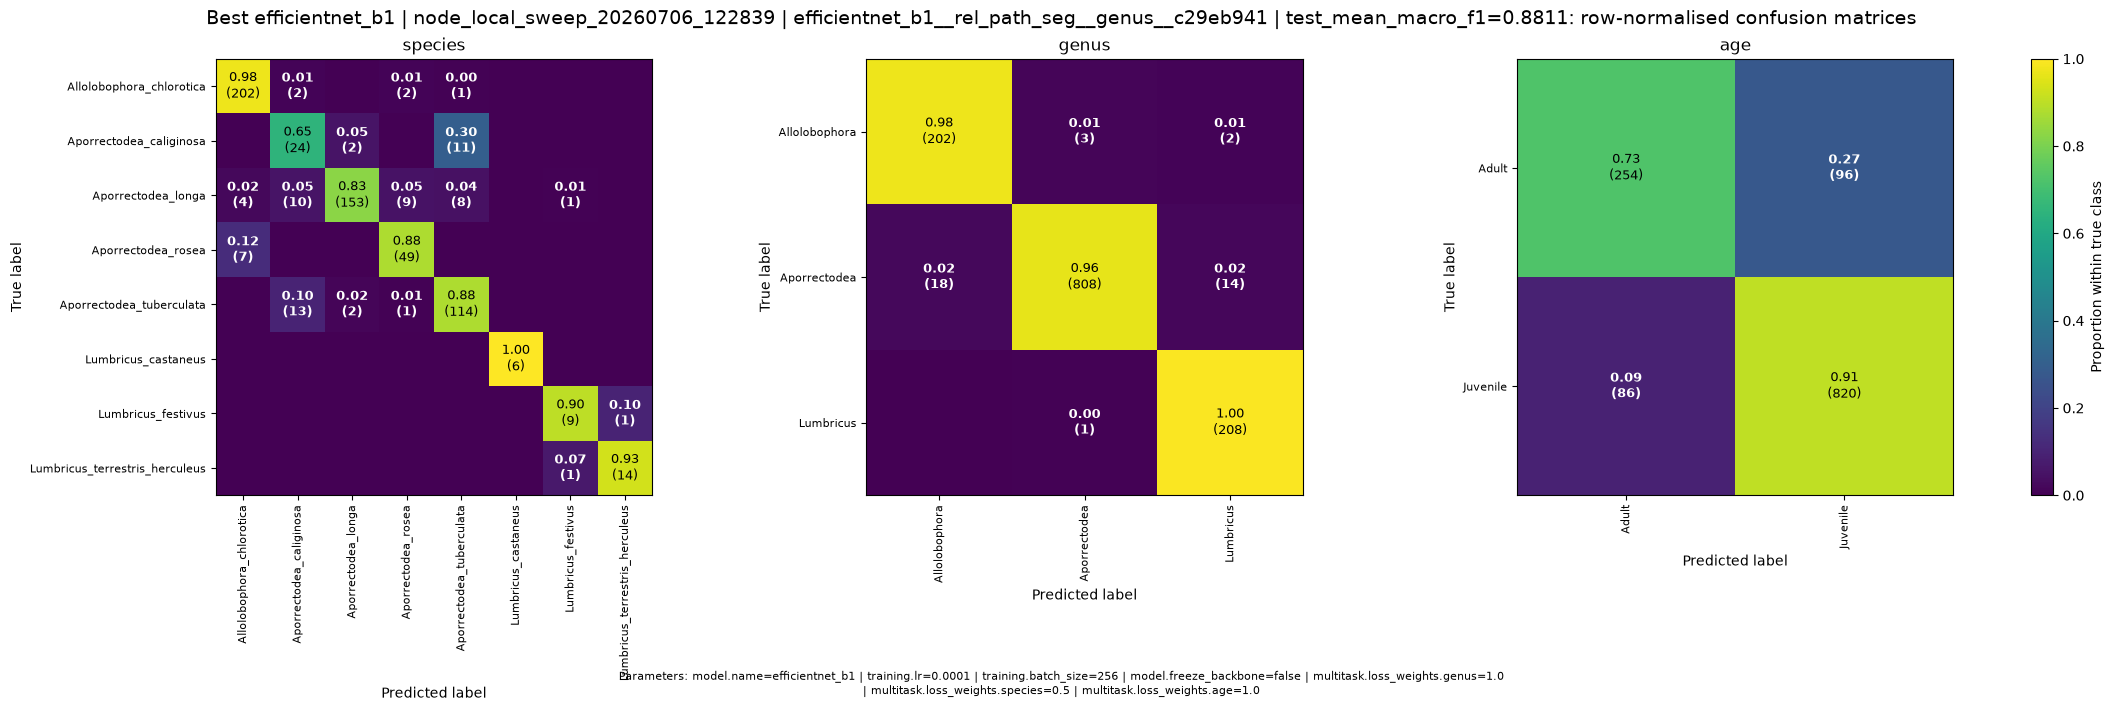

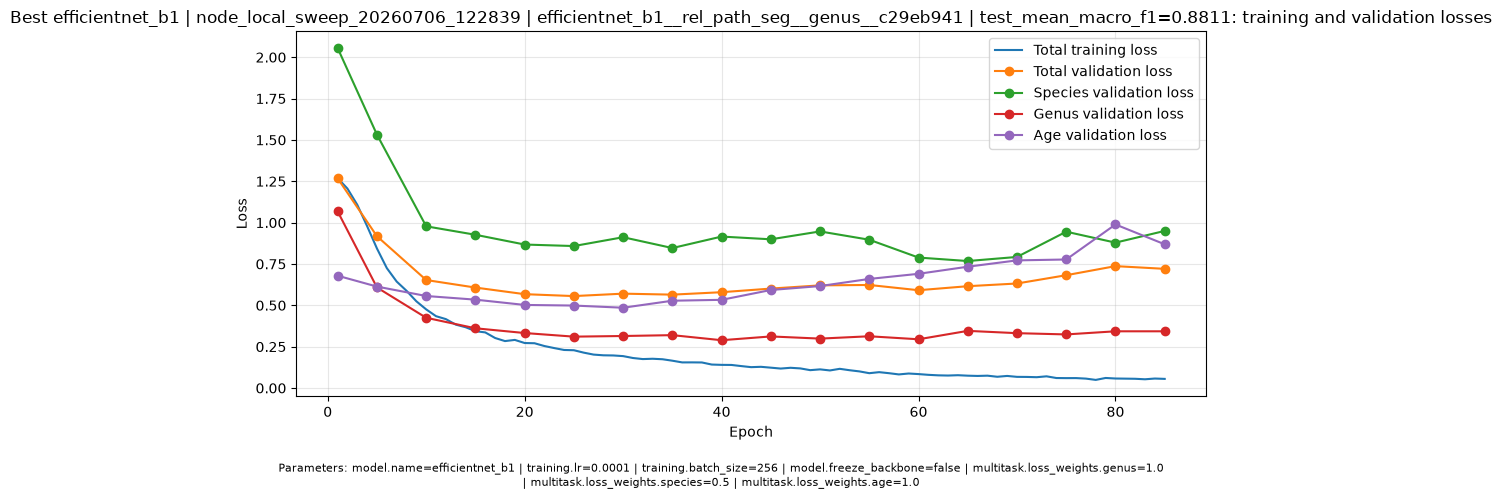

Best efficientnet_b0 | node_local_sweep_20260703_164317 | efficientnet_b0__rel_path_seg__genus__e84ef6e5 | test_mean_macro_f1=0.8762
Parameters: model.name=efficientnet_b0 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=0.5
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_031/efficientnet_b0__rel_path_seg__genus__e84ef6e5
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/efficientnet_b0__efficientnet_b0__rel_path_seg__genus__e84ef6e5


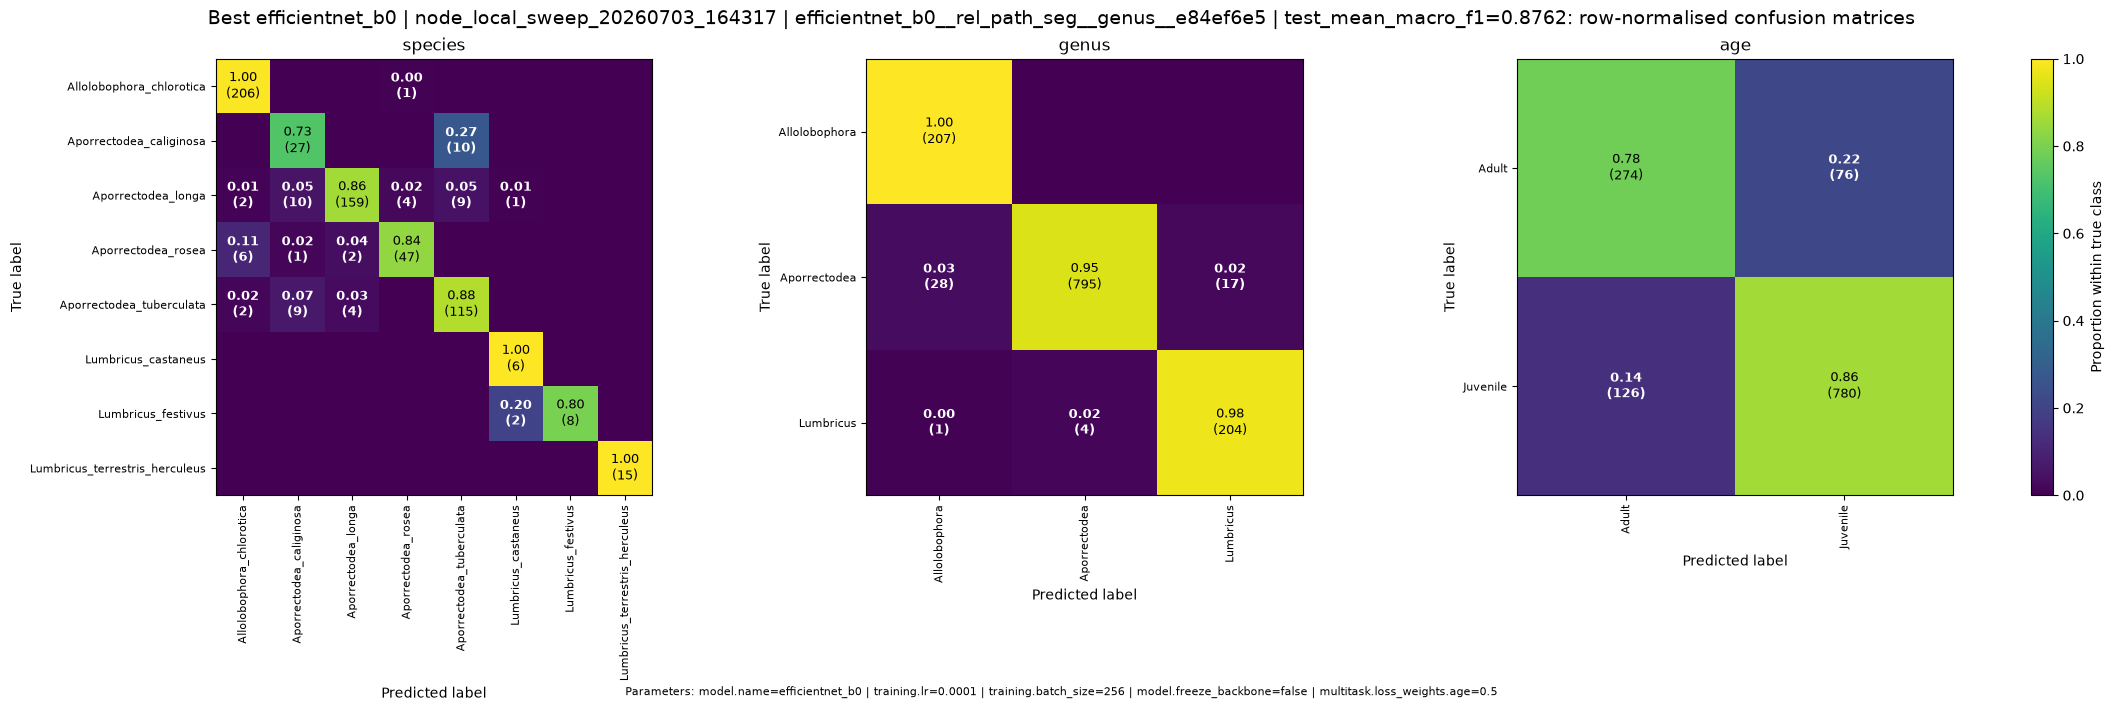

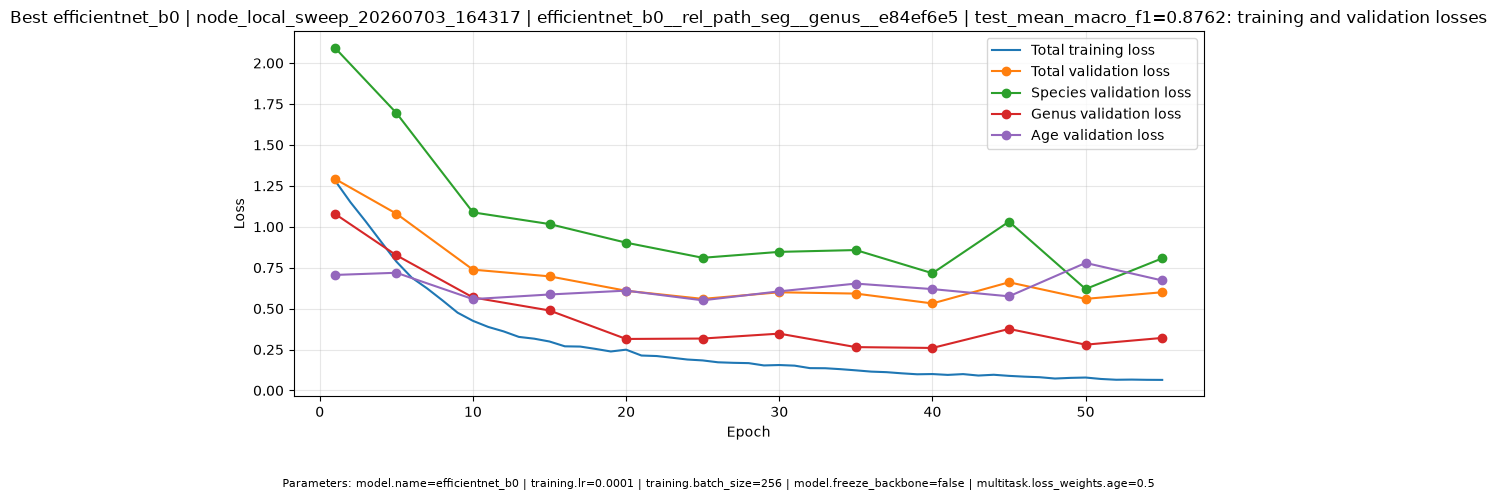

Best resnet50 | node_local_sweep_20260703_164317 | resnet50__rel_path_seg__genus__a72c4d66 | test_mean_macro_f1=0.8691
Parameters: model.name=resnet50 | training.lr=0.0001 | training.batch_size=256 | model.freeze_backbone=false | multitask.loss_weights.age=1.0
Model directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/node_local_sweep_20260703_164317/run_084/resnet50__rel_path_seg__genus__a72c4d66
Output directory: /usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/resnet50__resnet50__rel_path_seg__genus__a72c4d66


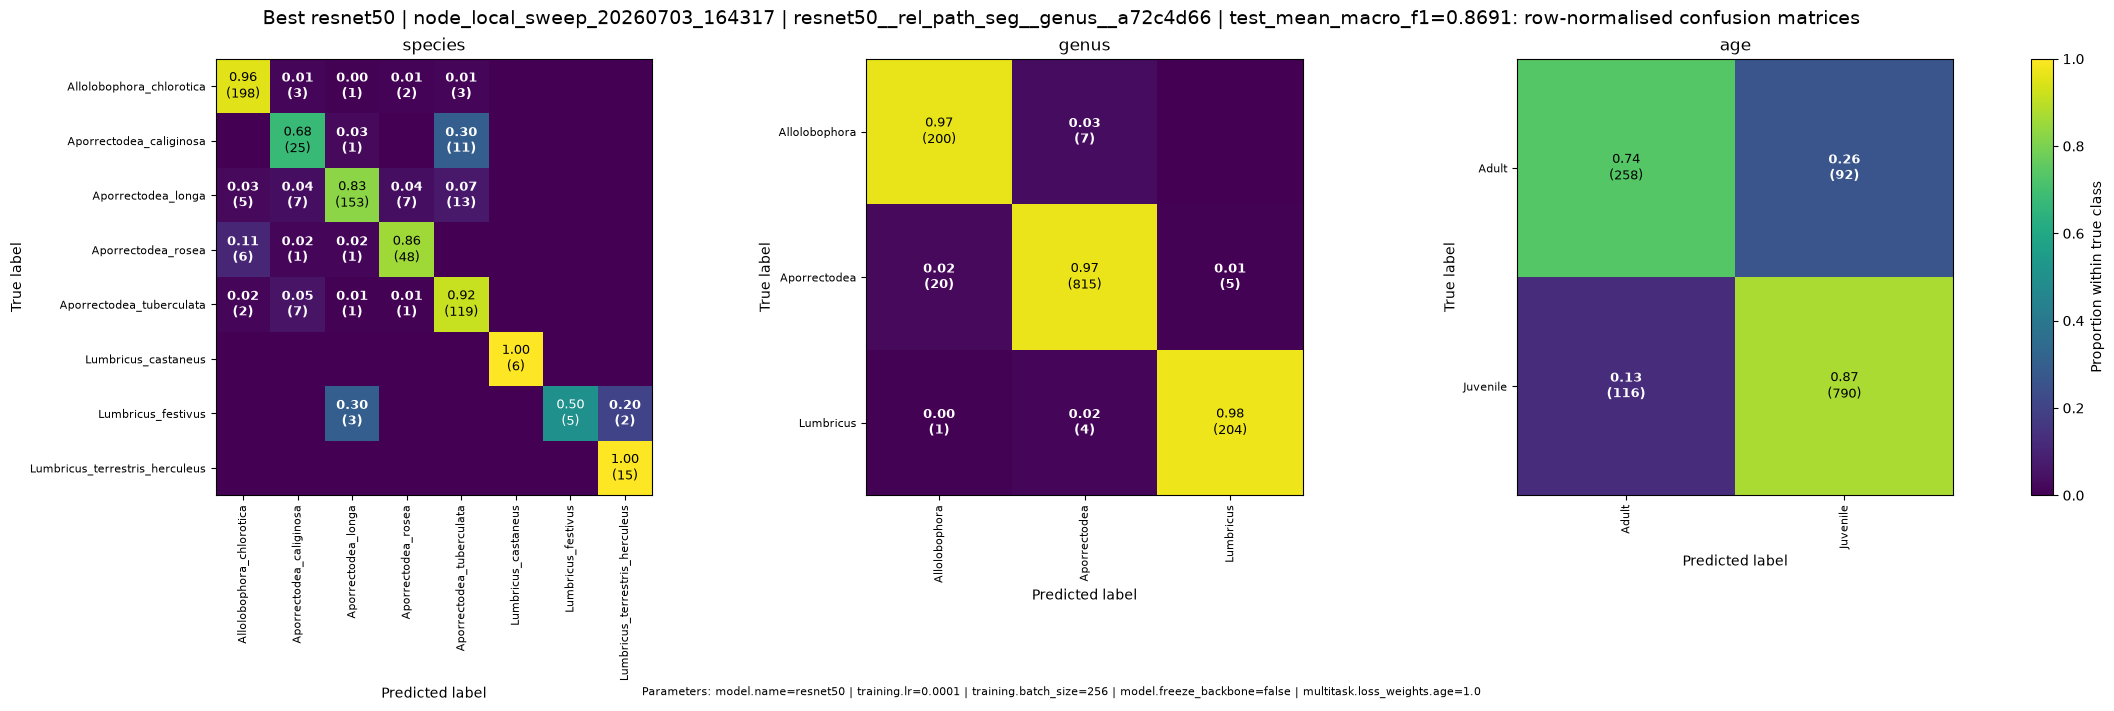

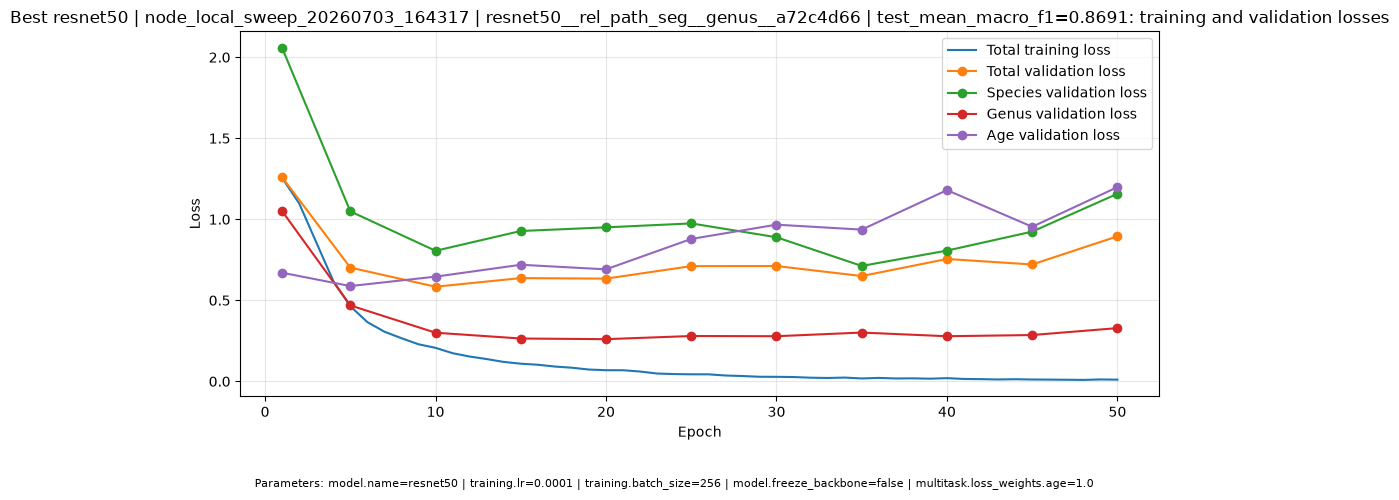


Saved plots:
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/convnext_base__convnext_base__rel_path_seg__genus__5ec55a00/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/convnext_base__convnext_base__rel_path_seg__genus__5ec55a00/training_and_validation_losses.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/vit_b_16__vit_b_16__rel_path_seg__genus__b63b4a48/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/vit_b_16__vit_b_16__rel_path_seg__genus__b63b4a48/training_and_validation_losses.png
/usr/home/qgg/mehrot/worm-species/outputs_slurm/combined_sweep_analysis/top_run_per_model_type/resnet18__resnet18__rel_path_seg__genus__68d3b62a/confusion_matrices_normalised_with_counts.png
/usr/home/qgg/mehrot/worm-species

In [33]:
all_saved_paths = []

for _, row in top_by_model.iterrows():
    model_dir = Path(row["artifact_dir"]).resolve()

    model_type = row["model_type"]
    run_name = row["run_name"]
    score = row[RANK_BY]

    override_text, override_path = read_run_overrides(row)
    parameter_summary = compact_overrides_text(override_text)

    run_label = (
        f"Best {model_type} | "
        f"{row.get('sweep_id', '')} | "
        f"{run_name} | "
        f"{RANK_BY}={score:.4f}"
    )

    run_figure_dir = TOP_BY_MODEL_FIGURE_DIR / f"{safe_slug(model_type)}__{safe_slug(run_name)}"
    run_table_dir = TOP_BY_MODEL_TABLE_DIR / f"{safe_slug(model_type)}__{safe_slug(run_name)}"
    run_figure_dir.mkdir(parents=True, exist_ok=True)
    run_table_dir.mkdir(parents=True, exist_ok=True)

    # Save full run details.
    (run_table_dir / "run_overrides.args").write_text(
        override_text if override_text else "run_overrides.args not found"
    )

    (run_table_dir / "run_summary.txt").write_text(
        "\n".join(
            [
                run_label,
                f"Model type: {model_type}",
                f"Model directory: {model_dir}",
                f"Override file: {override_path if override_path is not None else 'not found'}",
                "",
                "Compact parameter summary:",
                parameter_summary,
                "",
                "Full run_overrides.args:",
                override_text if override_text else "not found",
            ]
        )
    )

    print("=" * 100)
    print(run_label)
    print(parameter_summary)
    print("Model directory:", model_dir)
    print("Figure directory:", run_figure_dir)
    print("Table directory:", run_table_dir)

    cm_path = plot_all_confusion_matrices_normalised(
        model_dir=model_dir,
        out_dir=run_figure_dir,
        tasks=TASKS,
        run_label=run_label,
        parameter_summary=parameter_summary,
    )
    all_saved_paths.append(cm_path)

    loss_path = plot_task_losses(
        model_dir=model_dir,
        out_dir=run_figure_dir,
        run_label=run_label,
        parameter_summary=parameter_summary,
    )

    if loss_path is not None:
        all_saved_paths.append(loss_path)


print("\nSaved plots:")
for path in all_saved_paths:
    print(path)

## 12. Compact interpretation table

This table helps identify whether the selected run is balanced across species, genus, and age, or whether the mean score hides a weak task.


In [ ]:
metric_cols = [
    "test_species_accuracy", "test_species_balanced_accuracy", "test_species_macro_f1",
    "test_genus_accuracy", "test_genus_balanced_accuracy", "test_genus_macro_f1",
    "test_age_accuracy", "test_age_balanced_accuracy", "test_age_macro_f1",
    "test_mean_macro_f1",
    "test_complete_exact_match_accuracy",
]

metric_cols = [c for c in metric_cols if c in ranked.columns]

best_metrics_table = (
    best_row[metric_cols]
    .to_frame("selected_best_run")
)

# Add the best observed value for each metric to show whether the selected model is also metric-wise best.
best_metric_values = {}
best_metric_runs = {}

for col in metric_cols:
    idx = ranked[col].astype(float).idxmax()
    best_metric_values[col] = ranked.loc[idx, col]
    best_metric_runs[col] = ranked.loc[idx, "run_name"]

best_metrics_table["best_value_in_sweep"] = pd.Series(best_metric_values)
best_metrics_table["run_with_best_value"] = pd.Series(best_metric_runs)

display(best_metrics_table)


,selected_best_run,best_value_in_sweep,run_with_best_value
test_species_accuracy,0.919505,0.919505,vit_b_16__rel_path_seg__genus__59bc06d2
test_species_balanced_accuracy,0.890075,0.916835,resnet18__rel_path_seg__genus__d5a1d7f5
test_species_macro_f1,0.894019,0.894019,vit_b_16__rel_path_seg__genus__59bc06d2
test_genus_accuracy,0.982484,0.982484,vit_b_16__rel_path_seg__genus__59bc06d2
test_genus_balanced_accuracy,0.977952,0.982455,resnet18__rel_path_seg__genus__8948bd0e
test_genus_macro_f1,0.976783,0.976783,vit_b_16__rel_path_seg__genus__59bc06d2
test_age_accuracy,0.853503,0.855096,efficientnet_b1__rel_path_seg__genus__ae35a08e
test_age_balanced_accuracy,0.837963,0.848679,resnet50__rel_path_seg__genus__80ebfe23
test_age_macro_f1,0.82458,0.824580,vit_b_16__rel_path_seg__genus__59bc06d2
test_mean_macro_f1,0.898461,0.898461,vit_b_16__rel_path_seg__genus__59bc06d2


## 13. Notes for interpretation

- Prefer `best_val_score` for selecting the model, especially for reporting results in a manuscript or thesis.
- Use `test_species_macro_f1` and the species-level confusion matrix to diagnose biological classification performance.
- Macro-F1 is usually more informative than raw accuracy when the earthworm dataset has class imbalance.
- Inspect classes with low support before drawing biological conclusions about species-level errors.
- Confusions between juvenile, genus-only, or uncertain labels should be interpreted cautiously, because they may reflect annotation granularity rather than purely visual model failure.
